In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.graph_objects as go

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import plotly.graph_objects as go

from lin_reg_utils import *

/home/jansapro/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
cities_df = pd.read_csv('../data/cities_with_all_data.csv')

cols = [
    'Nazev_obce_prijmy', 'Nejblizsi_nemocnice', 'Vzdalenost_km', 'Lat_x', 'Lon_x',
    'DPFO', 'DPPO', 'DPH',                      # fiscal variables (if available)
    'Total', 'age_15_64_total', 'age_0_14_total', 'Index_stari',  # demographics/size
    'Kraj'                                      # region FE (if available)
]

# Keep only columns that actually exist (prevents errors if some are missing)
existing_cols = [c for c in cols if c in cities_df.columns]
cities_df = cities_df[existing_cols].dropna()
cities_df.head()

# --- FIX: coerce numeric columns from strings to real numbers ---
numeric_cols = [c for c in [
    'Vzdalenost_km','Lat_x','Lon_x','DPFO','DPPO','DPH',
    'Total','age_15_64_total','age_0_14_total','Index_stari'
] if c in cities_df.columns]

for c in numeric_cols:
    # handles commas in numbers too (e.g. "1,234" or "12,5" depending on your data)
    cities_df[c] = (cities_df[c].astype(str)
                    .str.replace('\u00a0', '', regex=False)  # non-breaking space
                    .str.replace(' ', '', regex=False)
                    .str.replace(',', '.', regex=False))
    cities_df[c] = pd.to_numeric(cities_df[c], errors='coerce')

cities_df = cities_df.dropna(subset=numeric_cols)

In [4]:

# -----------------------
# 3) Construct variables
# -----------------------
# Per-capita / per-group measures (only if inputs exist)
if {'DPFO', 'Total'}.issubset(cities_df.columns):
    cities_df['DPFO_per_capita'] = cities_df['DPFO'] / cities_df['Total']

if {'DPPO', 'Total'}.issubset(cities_df.columns):
    cities_df['DPPO_per_capita'] = cities_df['DPPO'] / cities_df['Total']

if {'DPH', 'Total'}.issubset(cities_df.columns):
    cities_df['DPH_per_capita'] = cities_df['DPH'] / cities_df['Total']

# DPFO per working-age (if you want that "workforce normalization")
if {'DPFO', 'age_15_64_total'}.issubset(cities_df.columns):
    cities_df['DPFO_per_working_age'] = cities_df['DPFO'] / cities_df['age_15_64_total']

# Demographic shares
if {'age_0_14_total', 'Total'}.issubset(cities_df.columns):
    cities_df['Share_0_14'] = cities_df['age_0_14_total'] / cities_df['Total']

# Size
if 'Total' in cities_df.columns:
    cities_df['log_Total'] = np.log(cities_df['Total'].clip(lower=1))

# Replace inf/-inf created by divisions and drop resulting NaNs
cities_df = cities_df.replace([np.inf, -np.inf], np.nan).dropna()

# -----------------------
# 4) Drop extremes (winsor/trimming) - same style as your old notebook
# -----------------------
# Example: trim DPFO_per_capita (1% tails), only if it exists
if 'DPFO_per_capita' in cities_df.columns:
    lo = cities_df['DPFO_per_capita'].quantile(0.01)
    hi = cities_df['DPFO_per_capita'].quantile(0.99)
    cities_df = cities_df[(cities_df['DPFO_per_capita'] > lo) & (cities_df['DPFO_per_capita'] < hi)]
if 'DPFO_per_working_age' in cities_df.columns:
    lo = cities_df['DPFO_per_working_age'].quantile(0.01)
    hi = cities_df['DPFO_per_working_age'].quantile(0.99)
    cities_df = cities_df[(cities_df['DPFO_per_working_age'] > lo) & (cities_df['DPFO_per_working_age'] < hi)]


print(f"Number of rows after cleaning: {len(cities_df)}")

Number of rows after cleaning: 5497


In [5]:
formula = """
Vzdalenost_km ~ DPPO_per_capita + DPFO_per_capita + DPH_per_capita
+ DPFO_per_working_age + Index_stari + Share_0_14 + log_Total + C(Kraj)
"""

features_model = [
    'DPPO_per_capita', 'DPFO_per_capita', 'DPH_per_capita',
    'DPFO_per_working_age', 'Index_stari', 'Share_0_14', 'log_Total', 
]

model = smf.ols(formula, data=cities_df).fit(cov_type="HC3")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Vzdalenost_km   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     68.89
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          2.11e-192
Time:                        21:37:56   Log-Likelihood:                -17512.
No. Observations:                5497   AIC:                         3.506e+04
Df Residuals:                    5480   BIC:                         3.517e+04
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/home/jansapro/.local/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 15
  warnings.warn('covariance of constraints does not have full '


TEST LINEARITY


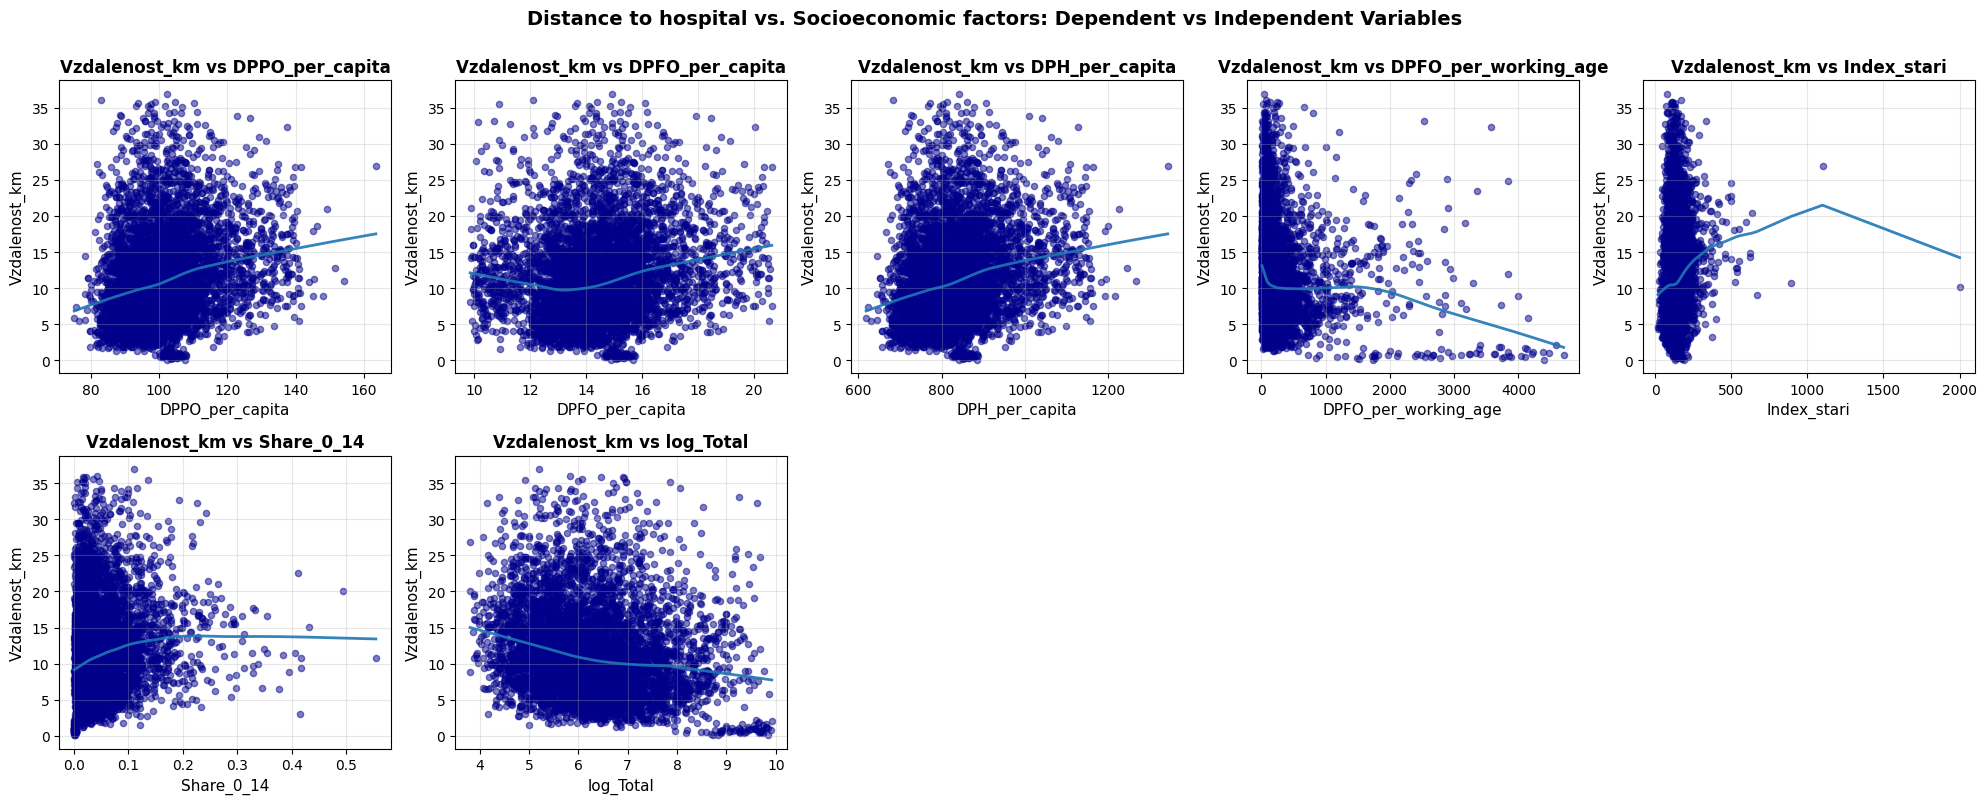

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



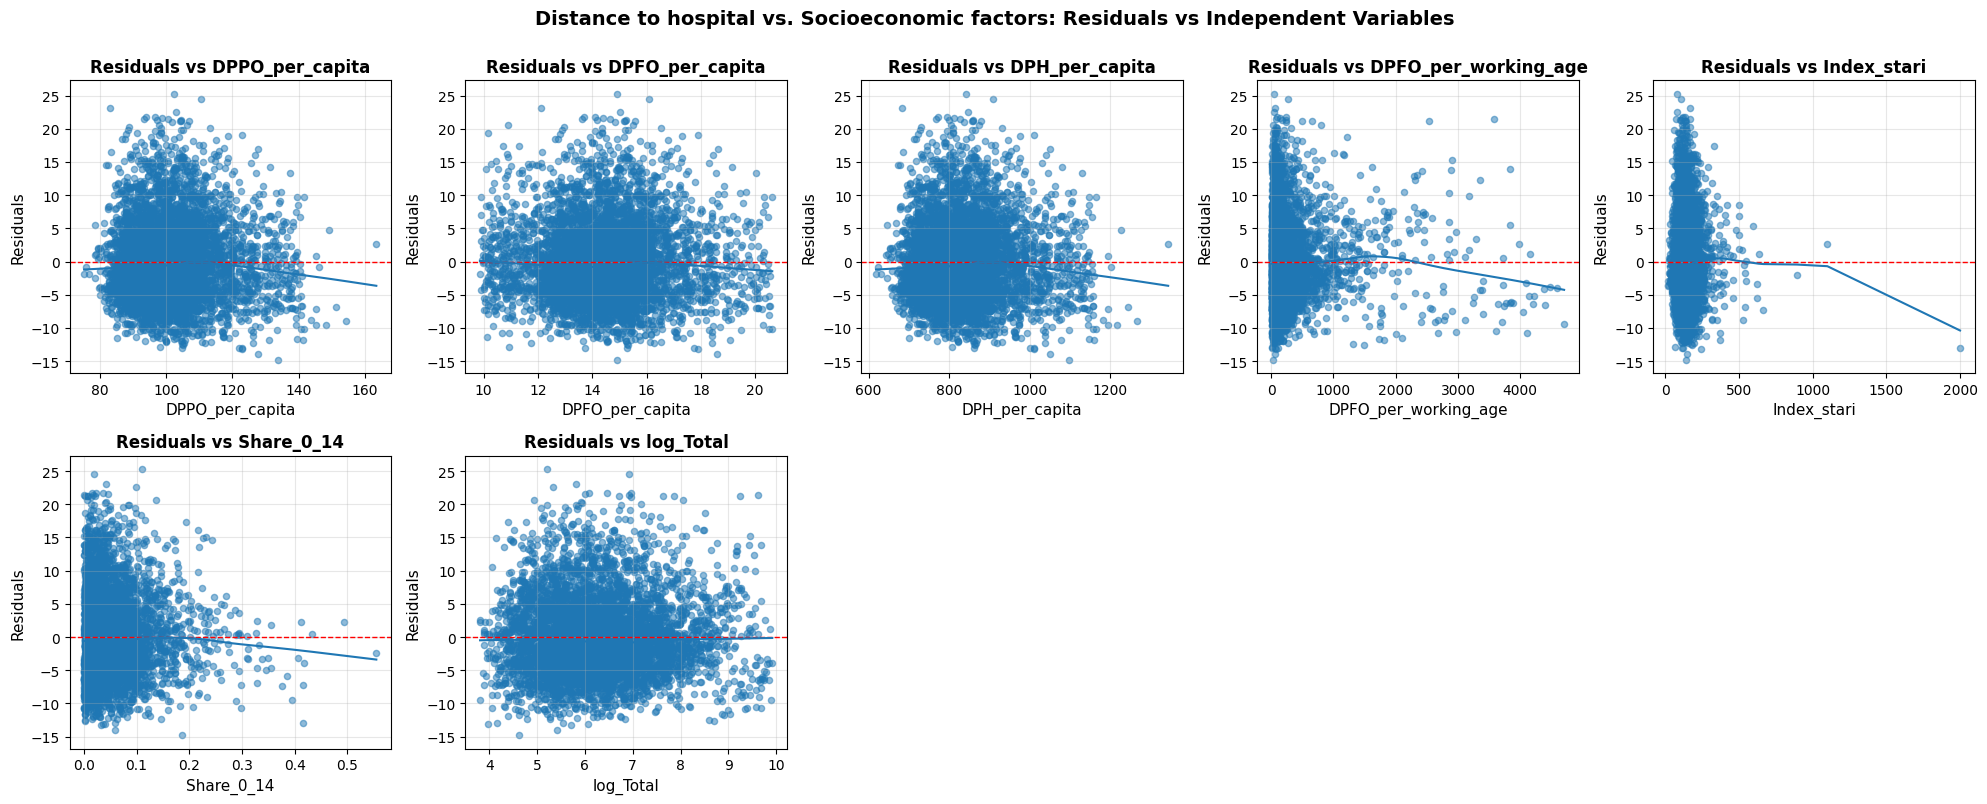

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Distance to hospital vs. Socioeconomic factors: 7.596e-120 (LM stat=615.454)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Distance to hospital vs. Socioeconomic factors: 1.418
Ljung–Box test results for Distance to hospital vs. Socioeconomic factors (lags [10, 20, 40]):
        lb_stat  lb_pvalue
10  3376.364238        0.0
20  5704.826223        0.0
40  7793.252010        0.0


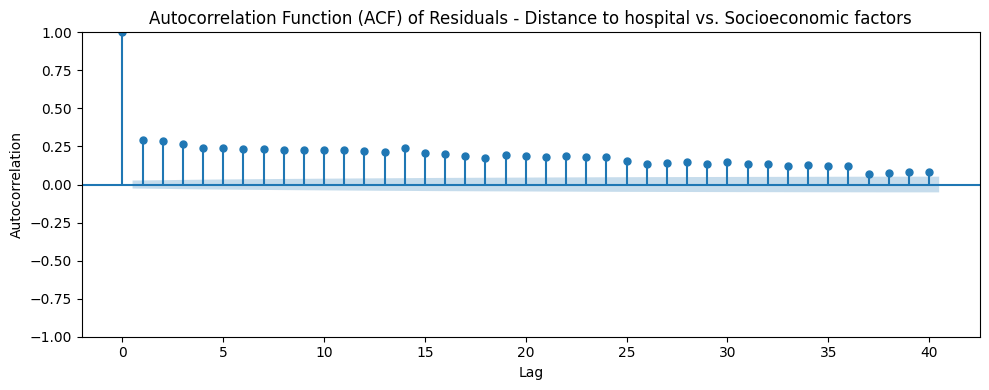

------------------------------------------------
TEST NORMALITY OF ERRORS


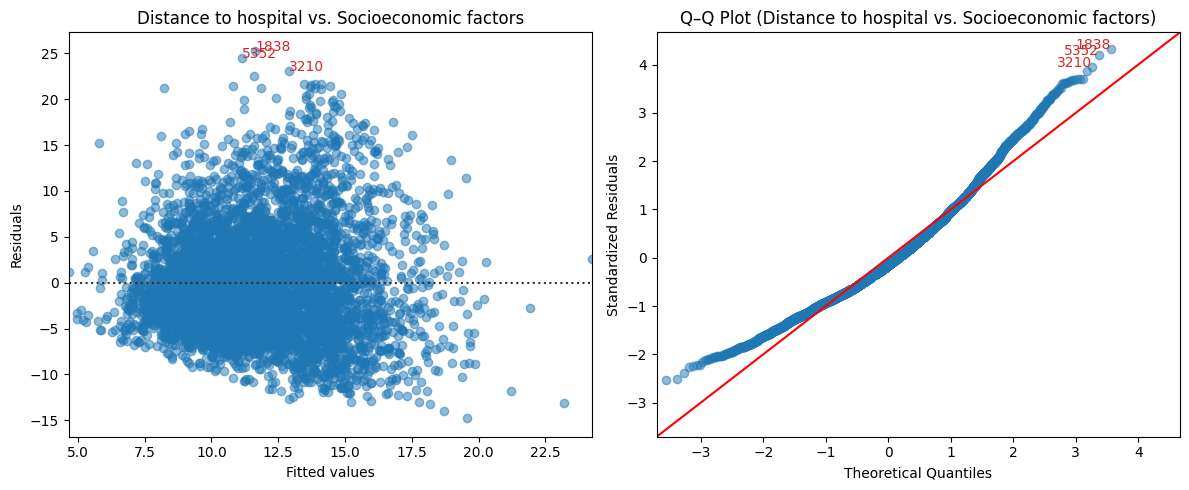

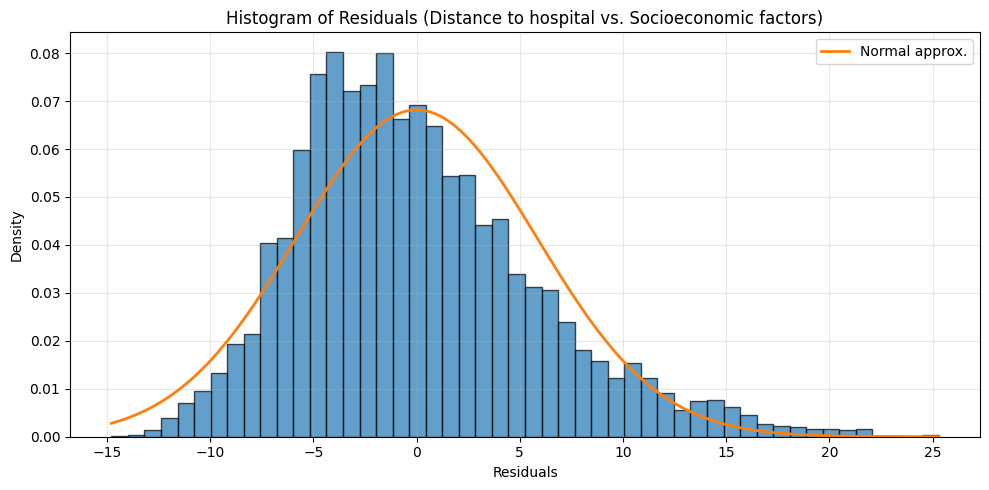

Shapiro–Wilk test for Distance to hospital vs. Socioeconomic factors: W=0.9660, p-value=3.782e-34
------------------------------------------------
TEST MULTICOLLINEARITY


/usr/lib/python3/dist-packages/scipy/stats/_morestats.py:1761: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


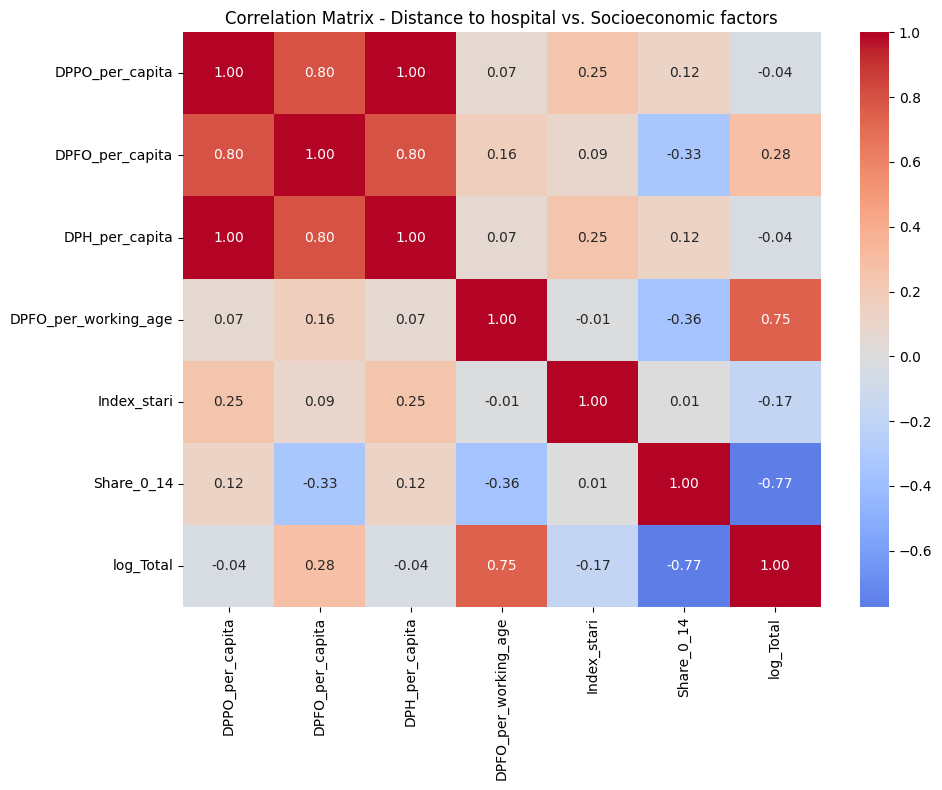

Variance Inflation Factor (VIF):
                      Features    VIF Factor
2         C(Kraj)[T.Jihozápad]  1.320000e+00
14                 Index_stari  1.520000e+00
4   C(Kraj)[T.Moravskoslezsko]  1.610000e+00
1        C(Kraj)[T.Jihovýchod]  1.780000e+00
5     C(Kraj)[T.Plzeňský kraj]  1.880000e+00
7       C(Kraj)[T.Severozápad]  1.950000e+00
3     C(Kraj)[T.Kraj Vysočina]  2.100000e+00
8    C(Kraj)[T.Střední Morava]  2.320000e+00
6      C(Kraj)[T.Severovýchod]  2.870000e+00
9     C(Kraj)[T.Střední Čechy]  2.900000e+00
13        DPFO_per_working_age  3.500000e+00
15                  Share_0_14  6.010000e+00
11             DPFO_per_capita  6.600000e+00
16                   log_Total  8.490000e+00
0                    Intercept  4.208500e+02
10             DPPO_per_capita  2.462666e+11
12              DPH_per_capita  2.462666e+11
------------------------------------------------


In [6]:
perform_all_tests(model, 
                  data_=cities_df, 
                  features=features_model, 
                  model_name="Distance to hospital vs. Socioeconomic factors",
                  y_col="Vzdalenost_km")

In [7]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# 1. Prepare Features (match your OLS formula)
# Handle categorical 'Kraj' via dummy encoding
X = pd.get_dummies(cities_df[[
    'DPPO_per_capita', 'DPFO_per_capita', 'DPH_per_capita', 
    'DPFO_per_working_age', 'Index_stari', 'Share_0_14', 
    'log_Total', 'Kraj'
]], drop_first=True)
y = cities_df['Vzdalenost_km']

# 2. Standardization is mandatory for LASSO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit LASSO with 5-fold Cross-Validation
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)

# 4. Create a DataFrame of results
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})
coef_df['Status'] = coef_df['Coefficient'].apply(lambda x: 'Kept' if x != 0 else 'Removed')

/tmp/ipykernel_177691/432541988.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)


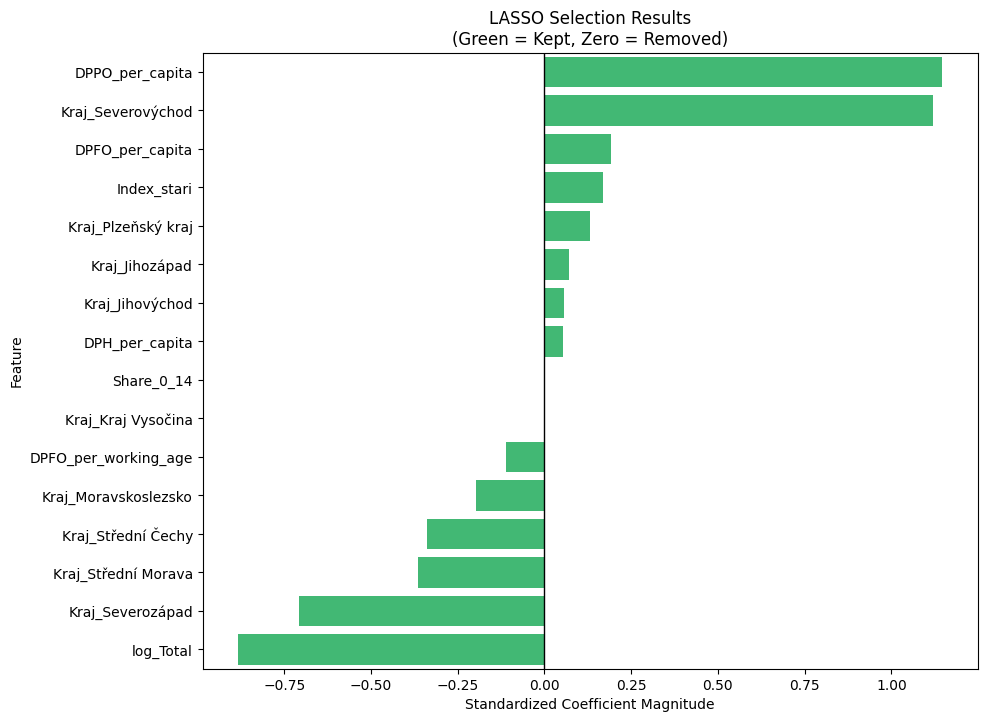

In [8]:
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if c != 0 else '#e74c3c' for c in coef_df['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)
plt.axvline(x=0, color='black', lw=1)
plt.title('LASSO Selection Results\n(Green = Kept, Zero = Removed)')
plt.xlabel('Standardized Coefficient Magnitude')
plt.show()

In [9]:
ols_features = []
kraj_kept = False

X = pd.get_dummies(cities_df[[
    'DPPO_per_capita', 'DPFO_per_capita', 'DPH_per_capita', 
    'DPFO_per_working_age', 'Index_stari', 'Share_0_14', 
    'log_Total', 'Kraj'
]], drop_first=True)

selected_features = X.columns[lasso.coef_ != 0].tolist()

for feat in selected_features:
    if "Kraj_" in feat:
        kraj_kept = True
    else:
        ols_features.append(feat)

keep_cols = ['Vzdalenost_km'] 

# Add the continuous features identified in your loop
keep_cols.extend(ols_features)

# Add the categorical 'Kraj' column if any region was kept
if kraj_kept:
    keep_cols.append('Kraj')

# 2. Create the new reduced DataFrame
cities_df_selected = cities_df[keep_cols].copy()

# Build the formula string
new_formula = "Vzdalenost_km ~ " + " + ".join(ols_features)
if kraj_kept:
    new_formula += " + C(Kraj)"

# Fit the final Post-LASSO OLS model
post_lasso_model = smf.ols(new_formula, data=cities_df).fit(cov_type="HC3")
print(post_lasso_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Vzdalenost_km   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     68.86
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          2.55e-192
Time:                        21:38:08   Log-Likelihood:                -17513.
No. Observations:                5497   AIC:                         3.506e+04
Df Residuals:                    5481   BIC:                         3.516e+04
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

TEST LINEARITY


/home/jansapro/.local/lib/python3.10/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


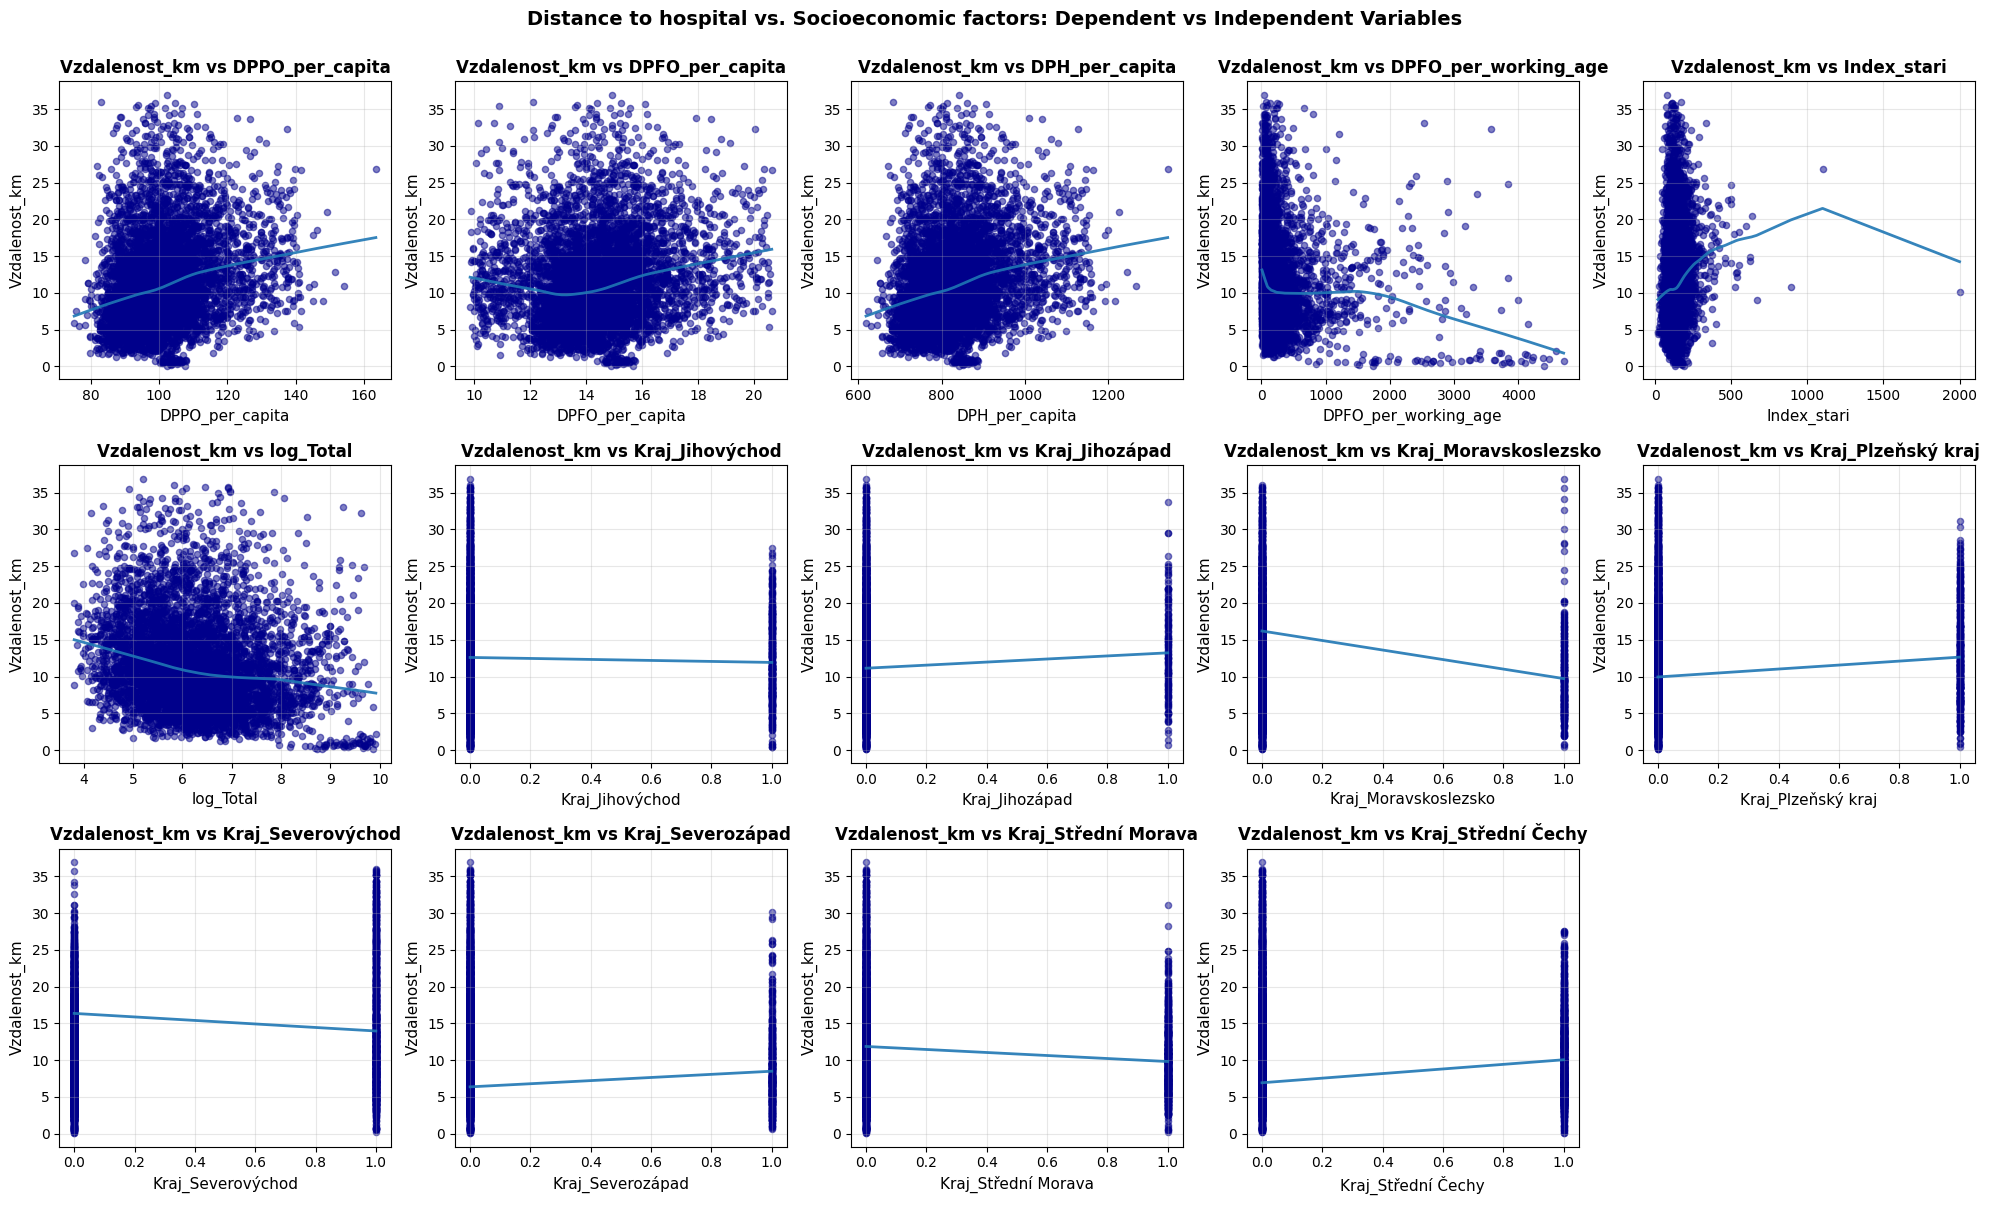

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



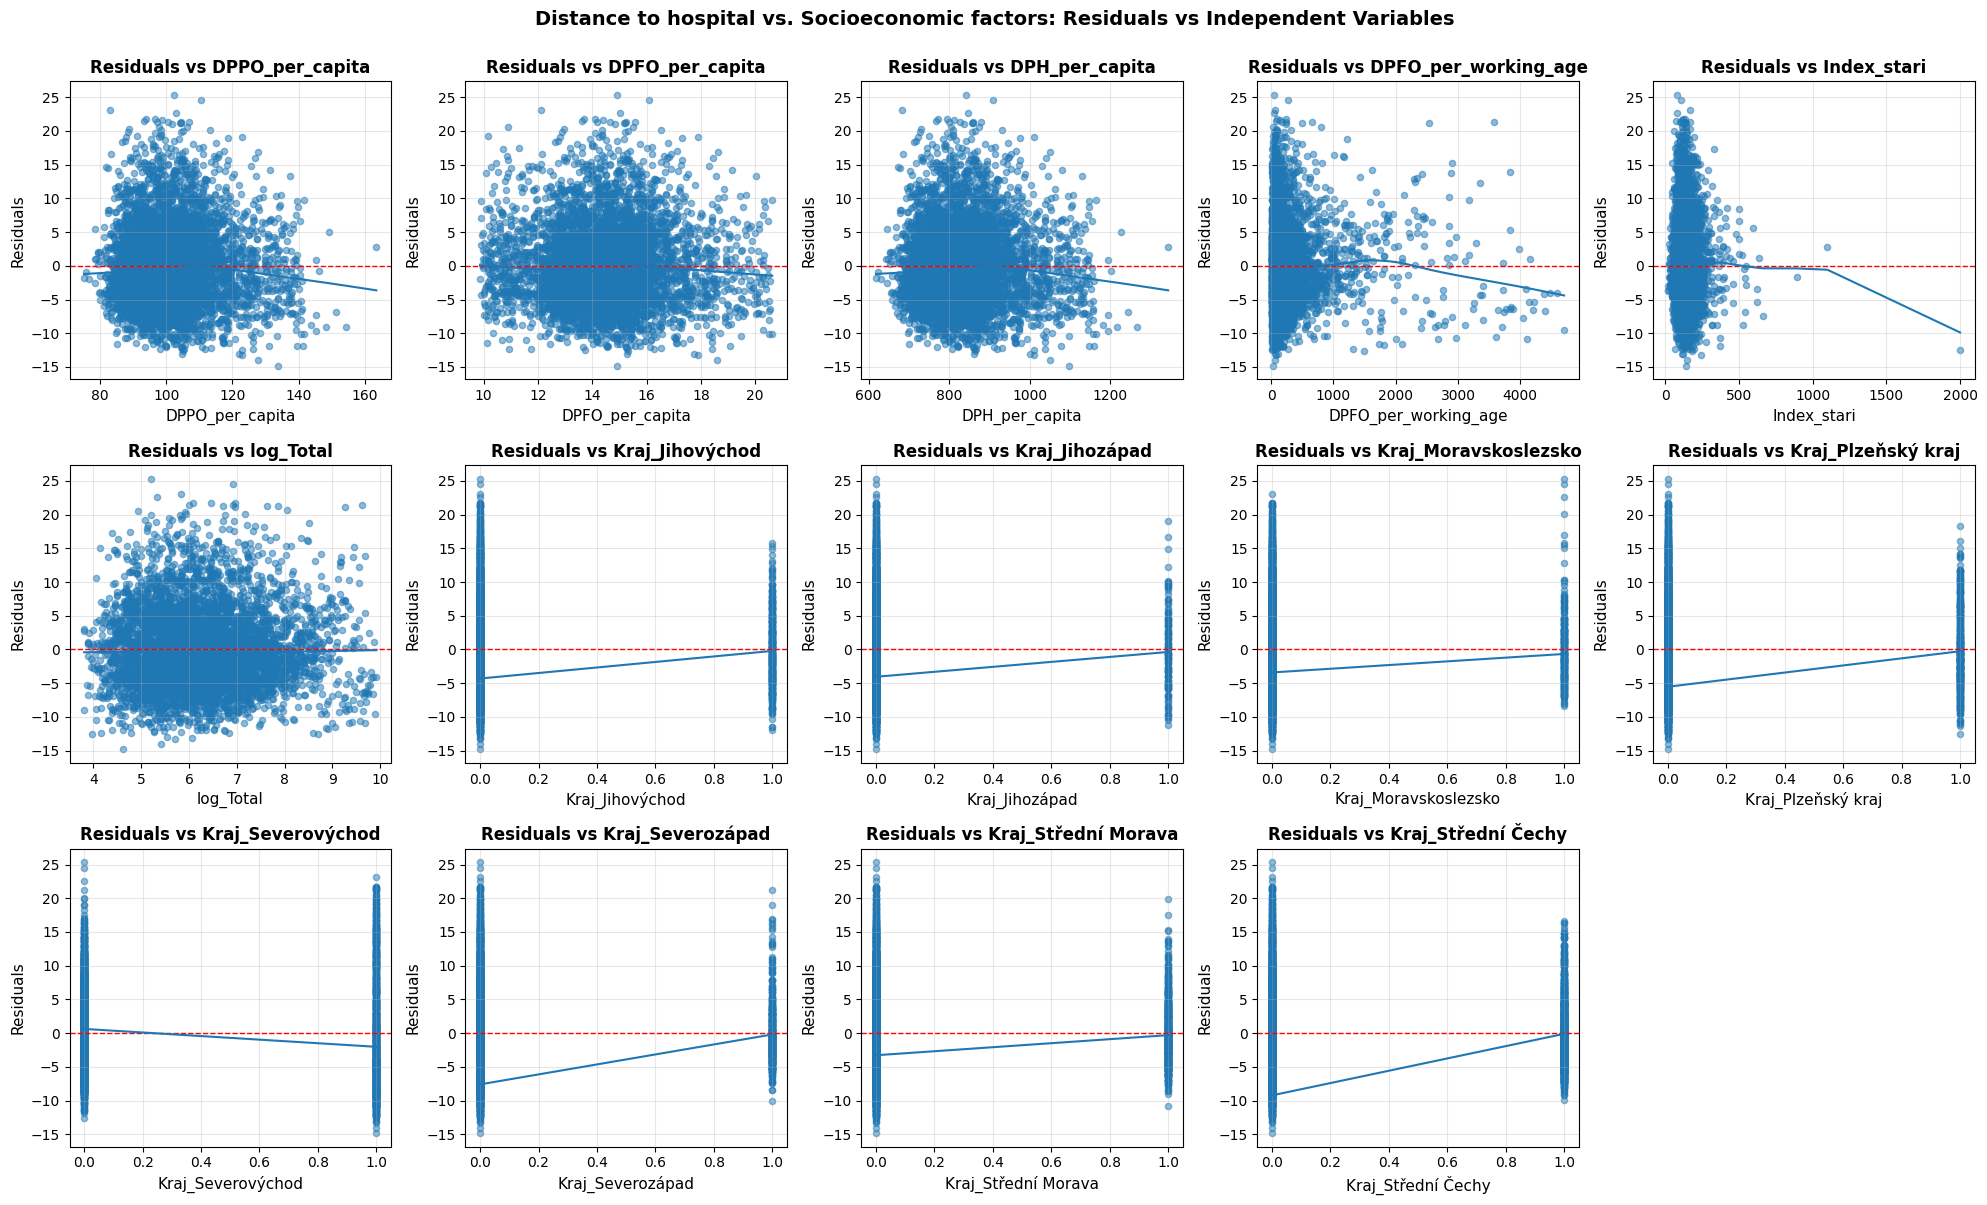

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Distance to hospital vs. Socioeconomic factors: 2.253e-120 (LM stat=614.171)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Distance to hospital vs. Socioeconomic factors: 1.418
Ljung–Box test results for Distance to hospital vs. Socioeconomic factors (lags [10, 20, 40]):
        lb_stat  lb_pvalue
10  3368.885019        0.0
20  5692.569727        0.0
40  7780.177770        0.0


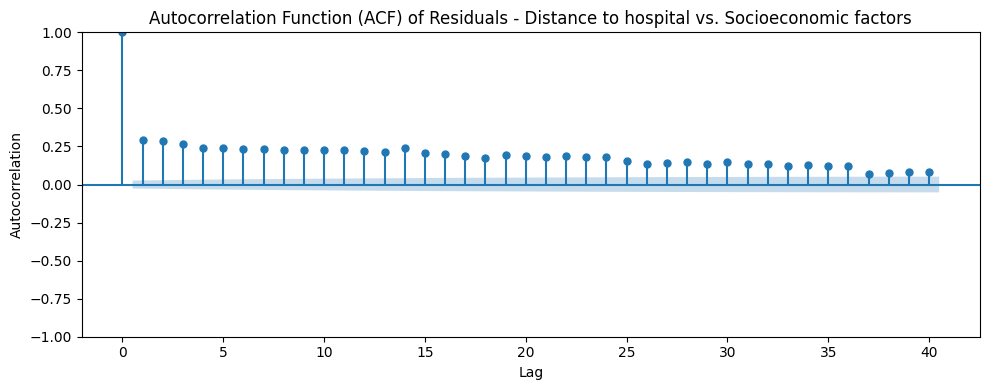

------------------------------------------------
TEST NORMALITY OF ERRORS


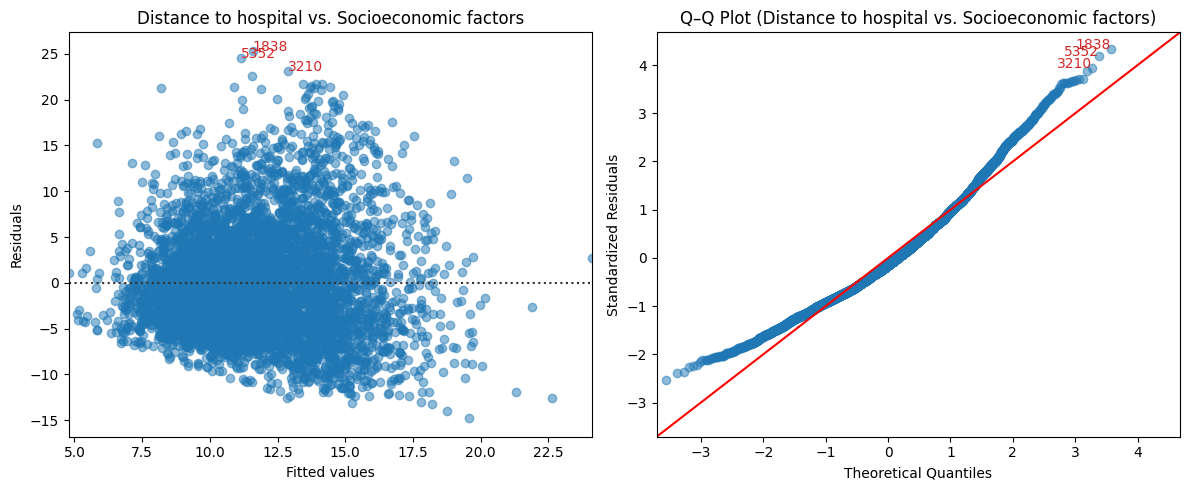

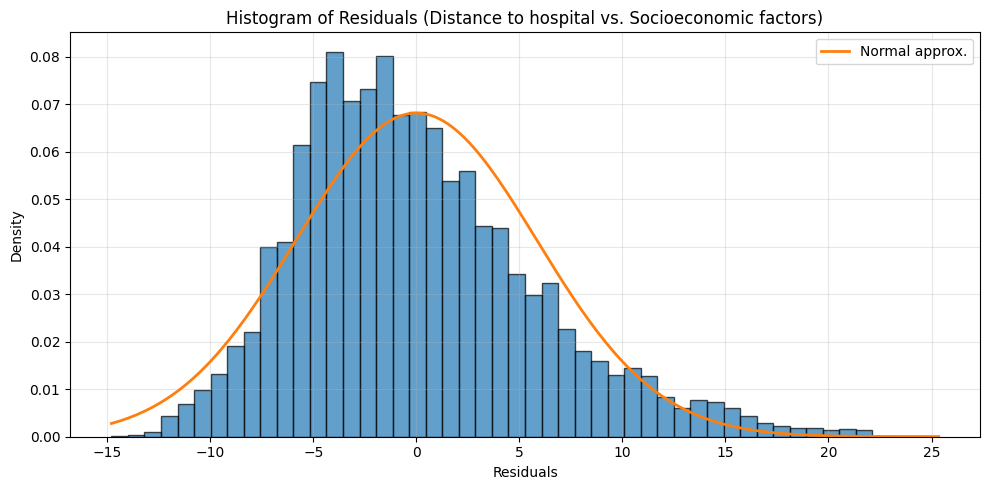

/usr/lib/python3/dist-packages/scipy/stats/_morestats.py:1761: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Shapiro–Wilk test for Distance to hospital vs. Socioeconomic factors: W=0.9660, p-value=4.075e-34
------------------------------------------------
TEST MULTICOLLINEARITY


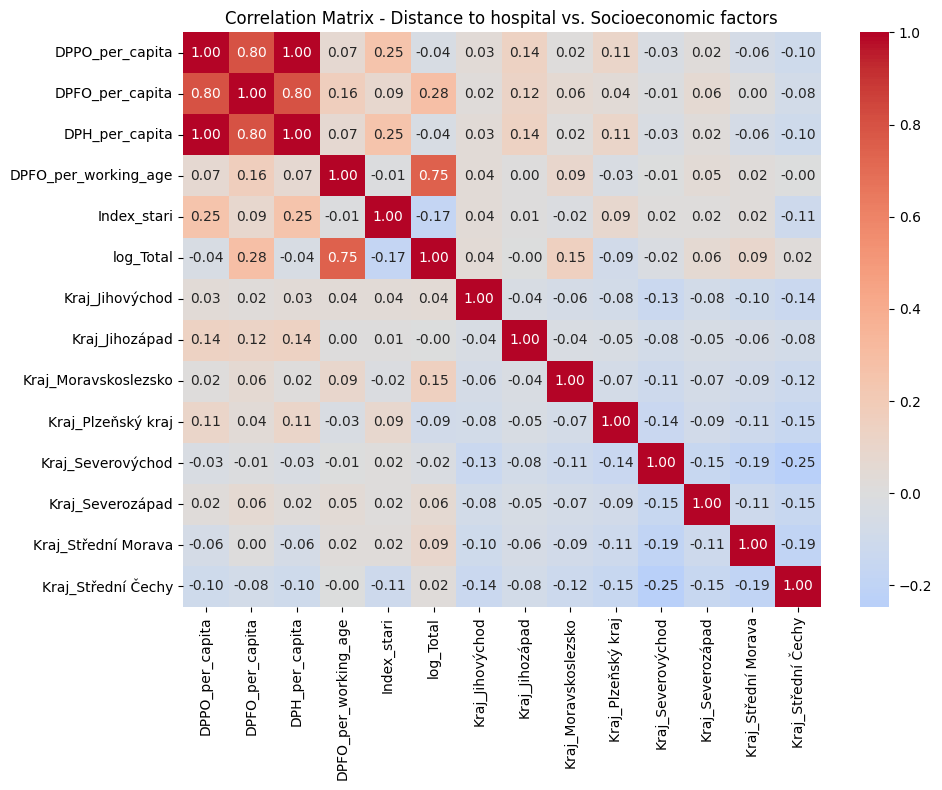

Variance Inflation Factor (VIF):
                      Features    VIF Factor
14                 Index_stari  1.150000e+00
2         C(Kraj)[T.Jihozápad]  1.320000e+00
4   C(Kraj)[T.Moravskoslezsko]  1.610000e+00
1        C(Kraj)[T.Jihovýchod]  1.780000e+00
5     C(Kraj)[T.Plzeňský kraj]  1.880000e+00
7       C(Kraj)[T.Severozápad]  1.950000e+00
3     C(Kraj)[T.Kraj Vysočina]  2.100000e+00
8    C(Kraj)[T.Střední Morava]  2.320000e+00
13        DPFO_per_working_age  2.730000e+00
6      C(Kraj)[T.Severovýchod]  2.860000e+00
9     C(Kraj)[T.Střední Čechy]  2.900000e+00
15                   log_Total  3.750000e+00
11             DPFO_per_capita  4.420000e+00
0                    Intercept  2.178100e+02
10             DPPO_per_capita  2.455549e+11
12              DPH_per_capita  2.455549e+11
------------------------------------------------


In [10]:
from lin_reg_utils import *

#y = post_lasso_model['Vzdalenost_km']
data_for_testing = pd.get_dummies(cities_df_selected, columns=['Kraj'], drop_first=True)
feature_cols = [col for col in X.columns if col != 'const']

perform_all_tests(post_lasso_model, 
                  data_=data_for_testing, 
                  features=selected_features, 
                  model_name="Distance to hospital vs. Socioeconomic factors",
                  y_col="Vzdalenost_km")

In [11]:
cols_to_trim = ['DPPO_per_capita', 'DPFO_per_capita', 'DPH_per_capita', 
                'DPFO_per_working_age', 'Index_stari', 'Share_0_14']

# for col in cols_to_trim:
#     if col in cities_df_selected.columns:
#         lo = cities_df_selected[col].quantile(0.01)
#         hi = cities_df_selected[col].quantile(0.99)
#         cities_df_selected = cities_df_selected[(cities_df_selected[col] > lo) & (cities_df_selected[col] < hi)]

# 2. Log-transform the dependent variable for better normality
cities_df_selected['log_distance_km'] = np.log(cities_df_selected['Vzdalenost_km'].clip(lower=0.1))

print(f"Final observation count after global trimming: {len(cities_df_selected)}")

Final observation count after global trimming: 5497


In [12]:
refined_formula = "log_distance_km ~ " + " + ".join(ols_features)
if kraj_kept:
    refined_formula += " + C(Kraj)"

# Fit the refined model with HC3 robust standard errors
refined_model = smf.ols(refined_formula, data=cities_df_selected).fit(cov_type="HC3")
print(refined_model.summary())


                            OLS Regression Results                            
Dep. Variable:        log_distance_km   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     70.17
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          7.36e-196
Time:                        21:38:25   Log-Likelihood:                -4646.6
No. Observations:                5497   AIC:                             9325.
Df Residuals:                    5481   BIC:                             9431.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [13]:
print(refined_model.summary2().tables[1])

                                 Coef.    Std.Err.         z         P>|z|  \
Intercept                     1.279871    0.129532  9.880693  5.048254e-23   
C(Kraj)[T.Jihovýchod]         0.012868    0.038550  0.333809  7.385237e-01   
C(Kraj)[T.Jihozápad]          0.002795    0.053211  0.052520  9.581140e-01   
C(Kraj)[T.Kraj Vysočina]     -0.014047    0.032546 -0.431610  6.660246e-01   
C(Kraj)[T.Moravskoslezsko]   -0.125889    0.042314 -2.975086  2.929063e-03   
C(Kraj)[T.Plzeňský kraj]      0.006109    0.036056  0.169421  8.654654e-01   
C(Kraj)[T.Severovýchod]       0.149764    0.031995  4.680897  2.856225e-06   
C(Kraj)[T.Severozápad]       -0.304459    0.035680 -8.533012  1.425855e-17   
C(Kraj)[T.Střední Morava]    -0.111882    0.031496 -3.552200  3.820248e-04   
C(Kraj)[T.Střední Čechy]     -0.111080    0.029361 -3.783262  1.547863e-04   
DPPO_per_capita             107.381134  285.979154  0.375486  7.072991e-01   
DPFO_per_capita               0.003717    0.008124  0.457568  6.

TEST LINEARITY


/home/jansapro/.local/lib/python3.10/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


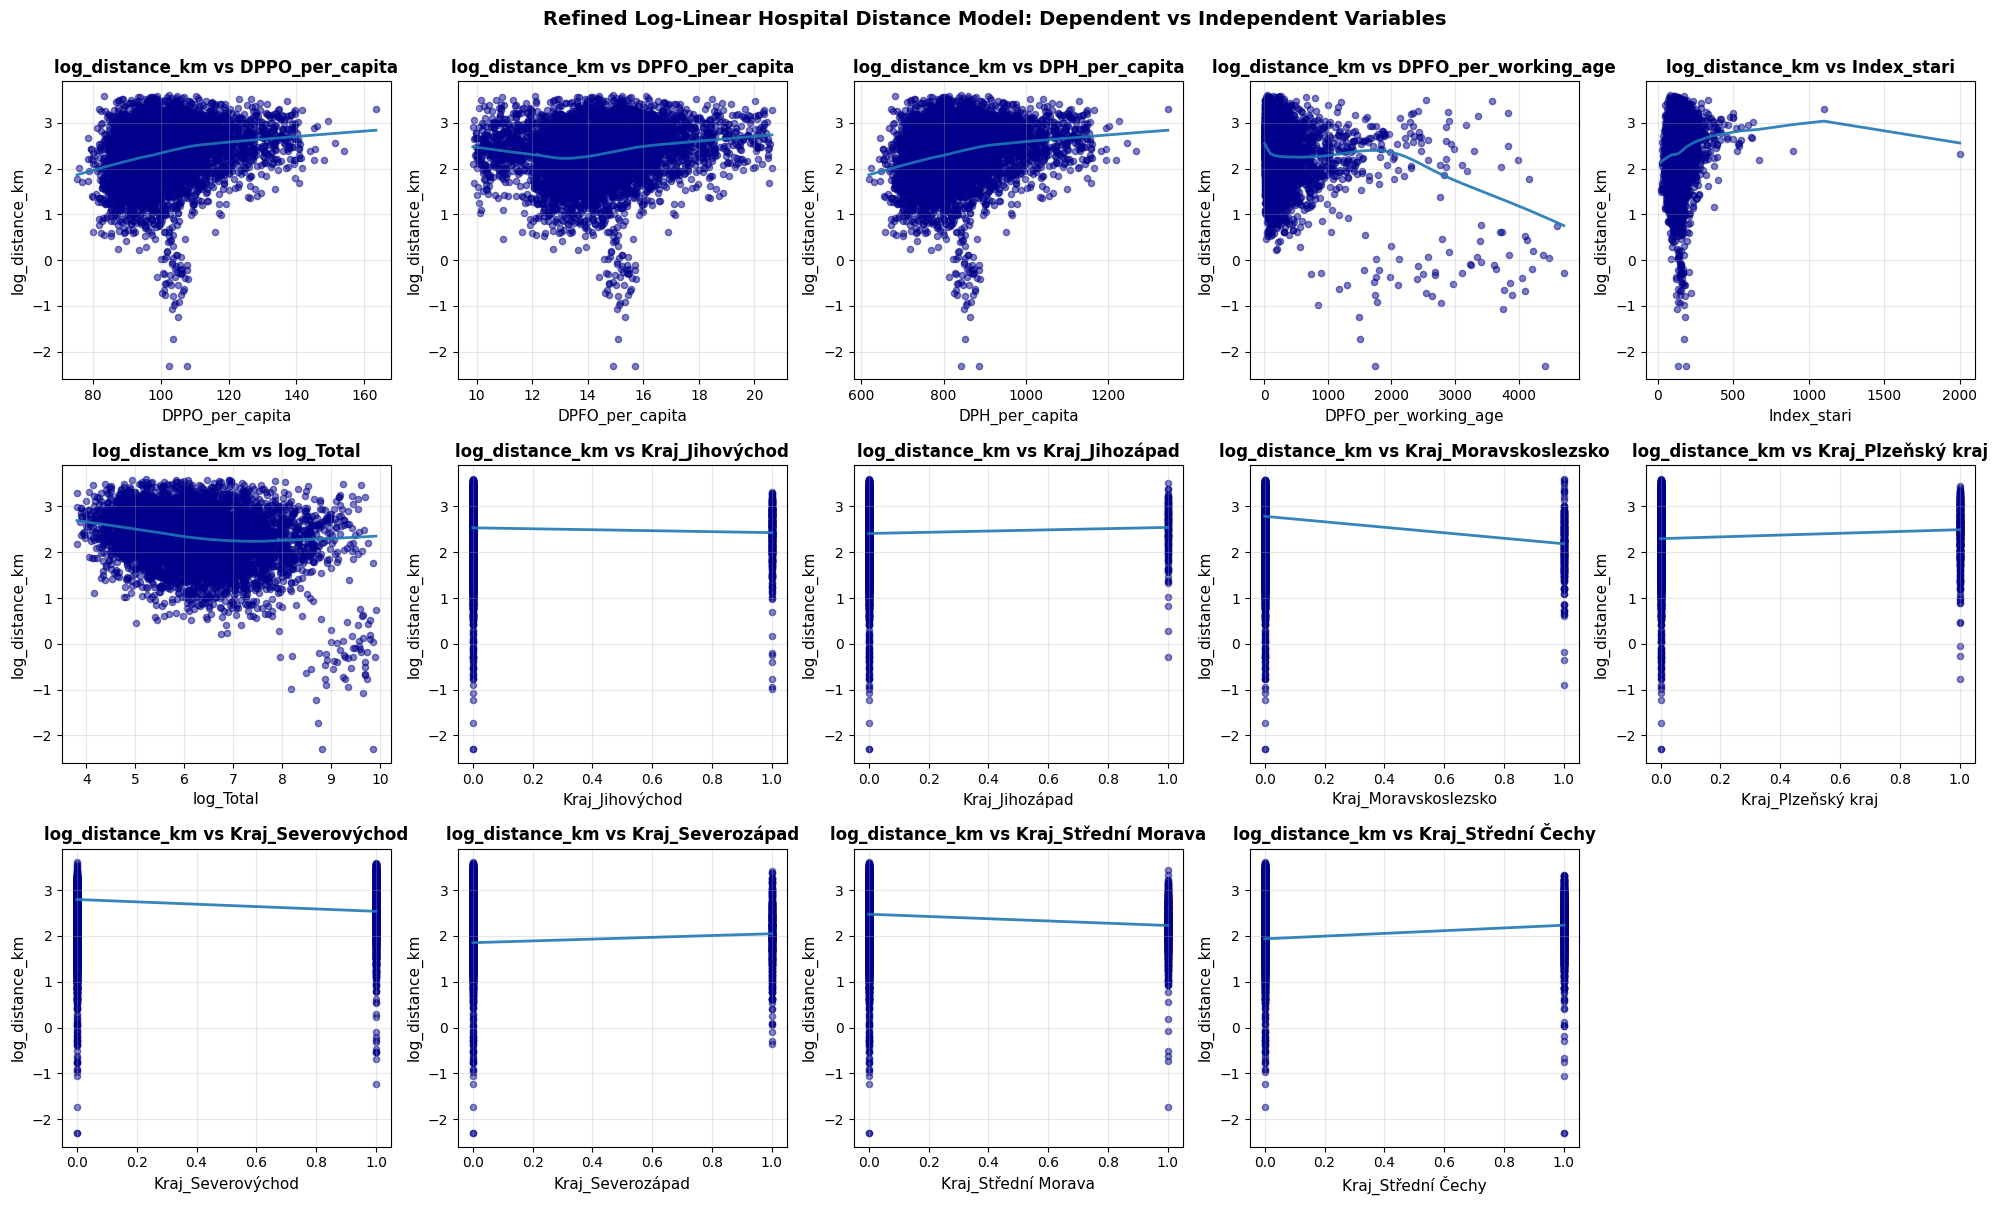

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



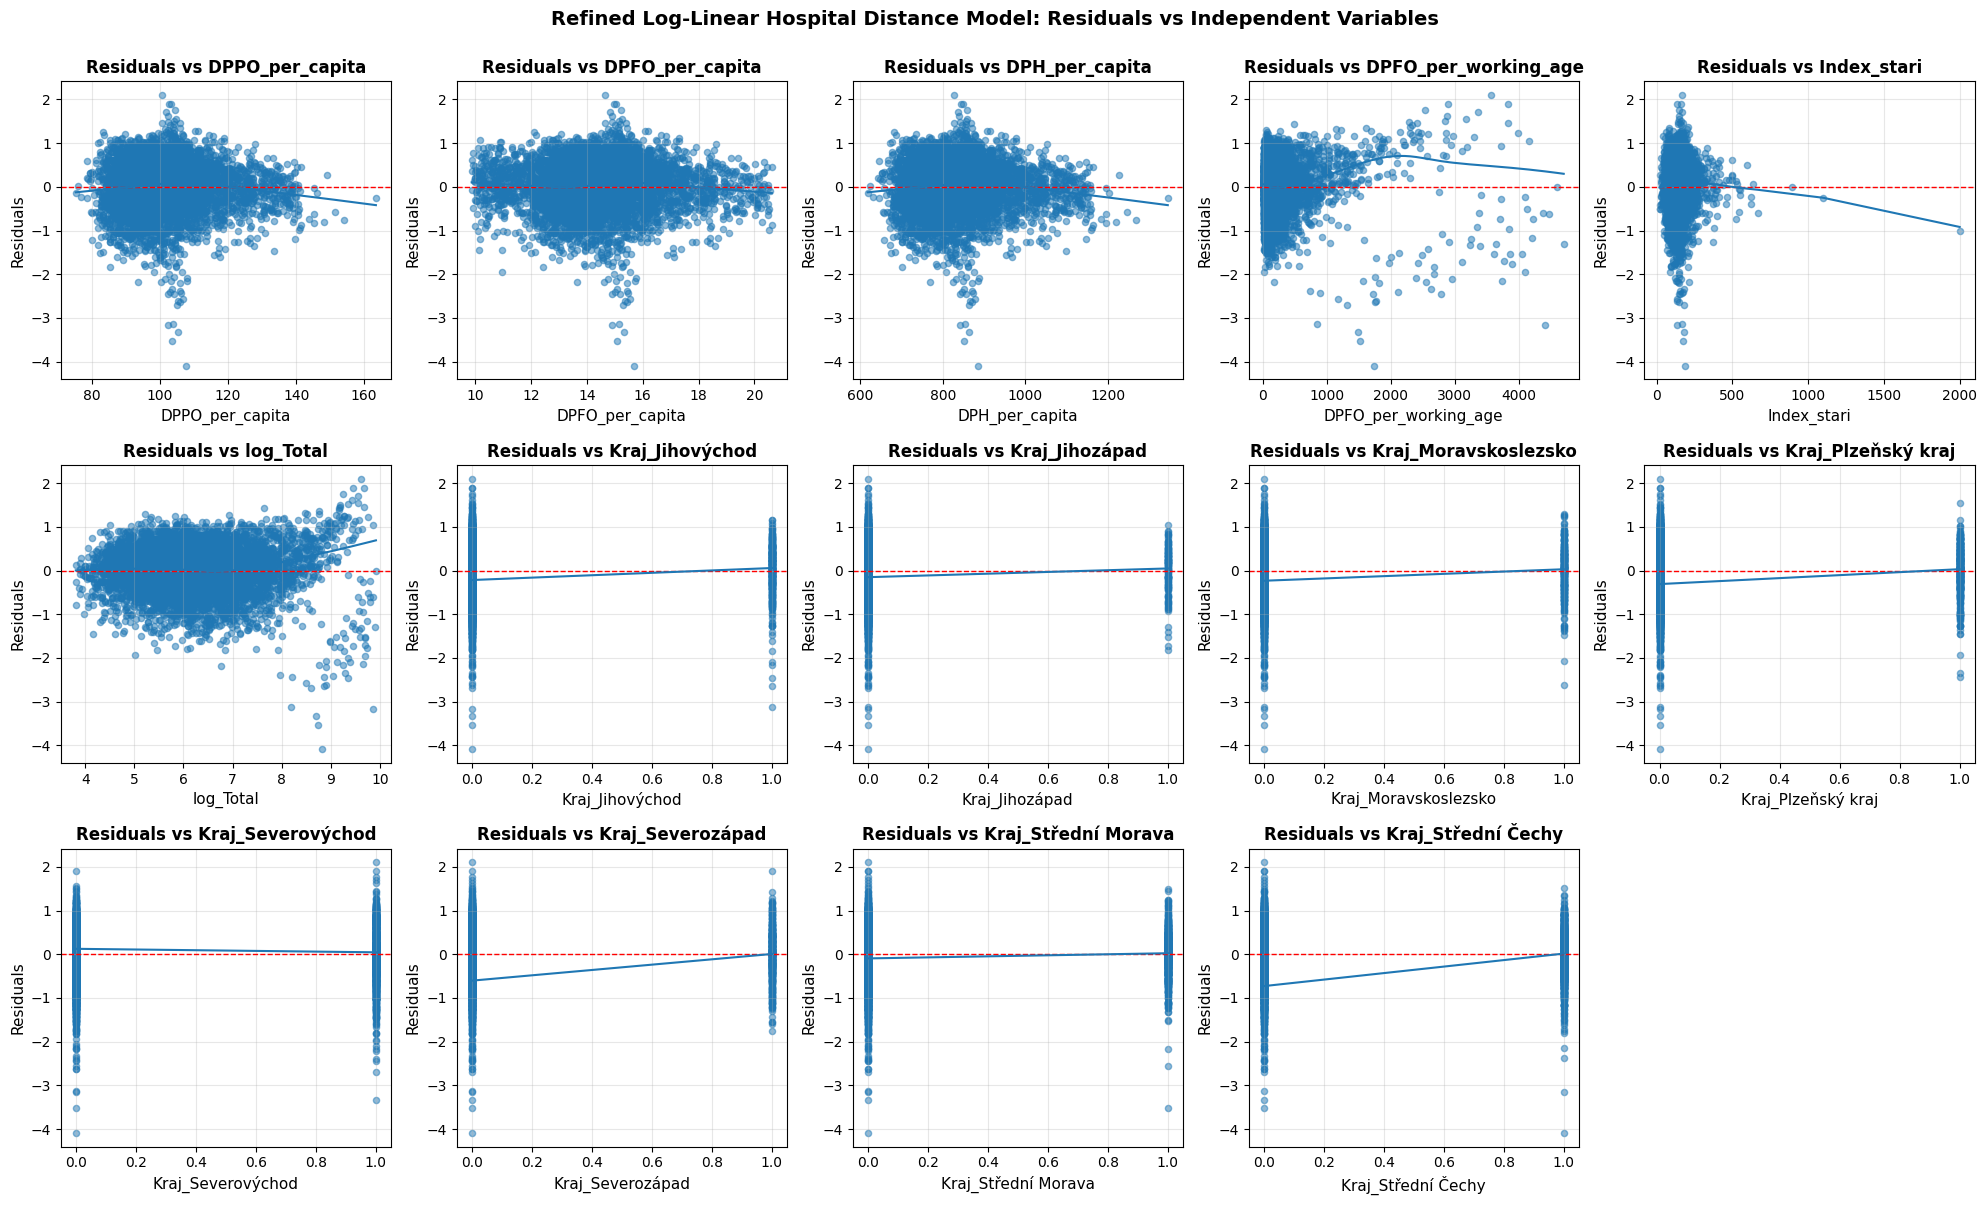

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Refined Log-Linear Hospital Distance Model: 3.748e-165 (LM stat=824.497)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Refined Log-Linear Hospital Distance Model: 1.591
Ljung–Box test results for Refined Log-Linear Hospital Distance Model (lags [10, 20, 40]):
        lb_stat      lb_pvalue
10  1414.365251  7.849880e-298
20  2439.934028   0.000000e+00
40  3302.493400   0.000000e+00


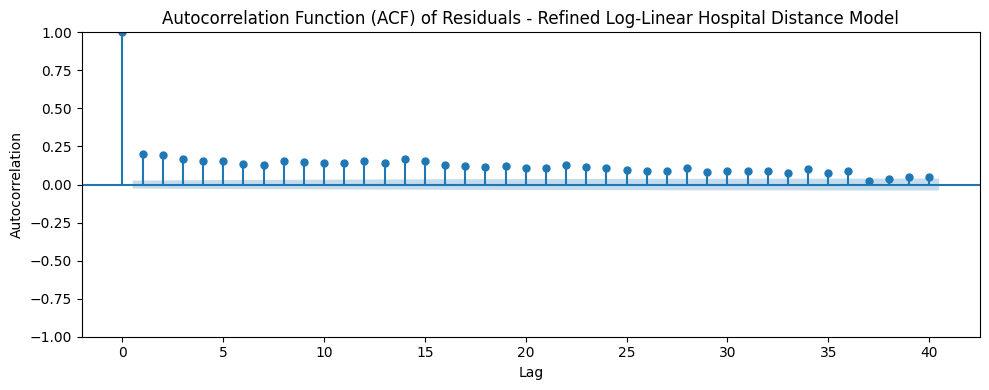

------------------------------------------------
TEST NORMALITY OF ERRORS


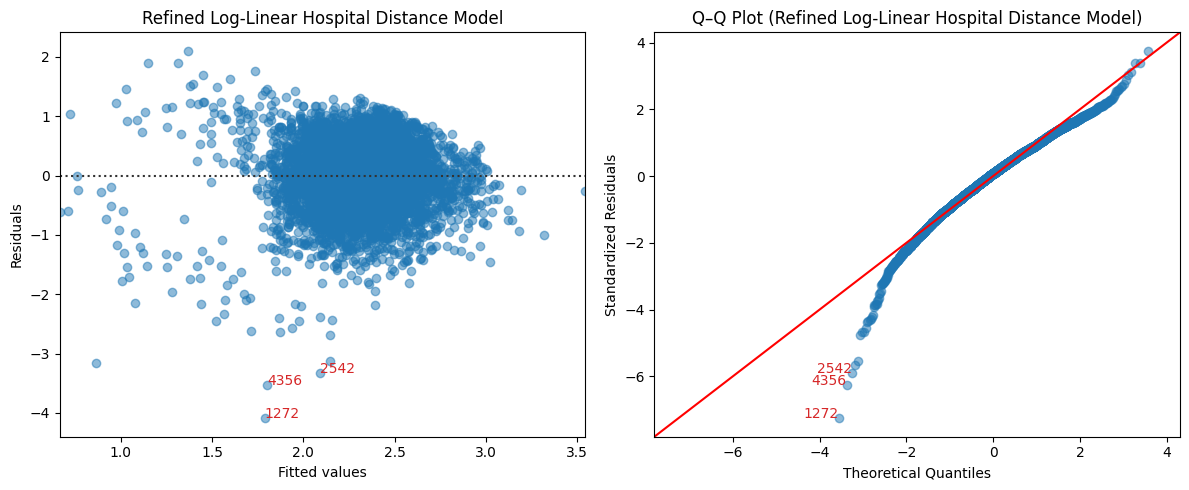

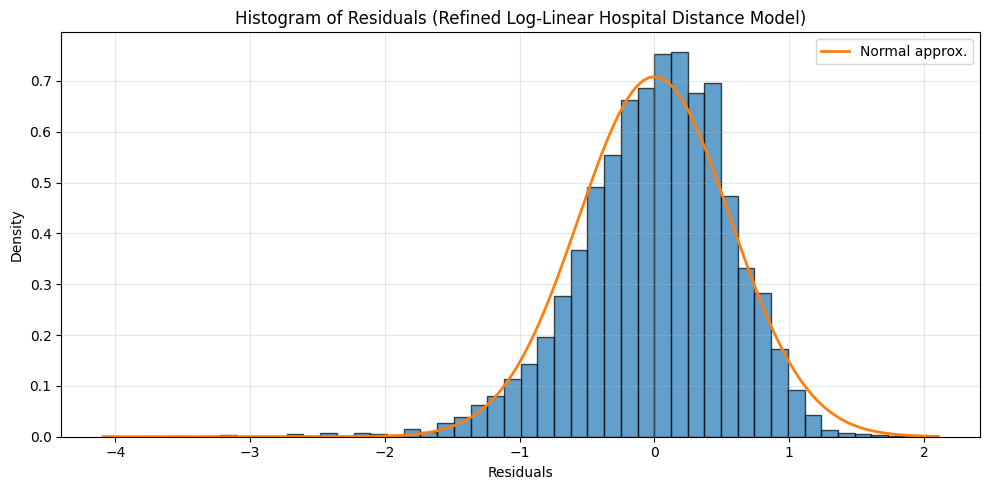

/usr/lib/python3/dist-packages/scipy/stats/_morestats.py:1761: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Shapiro–Wilk test for Refined Log-Linear Hospital Distance Model: W=0.9756, p-value=1.194e-29
------------------------------------------------
TEST MULTICOLLINEARITY


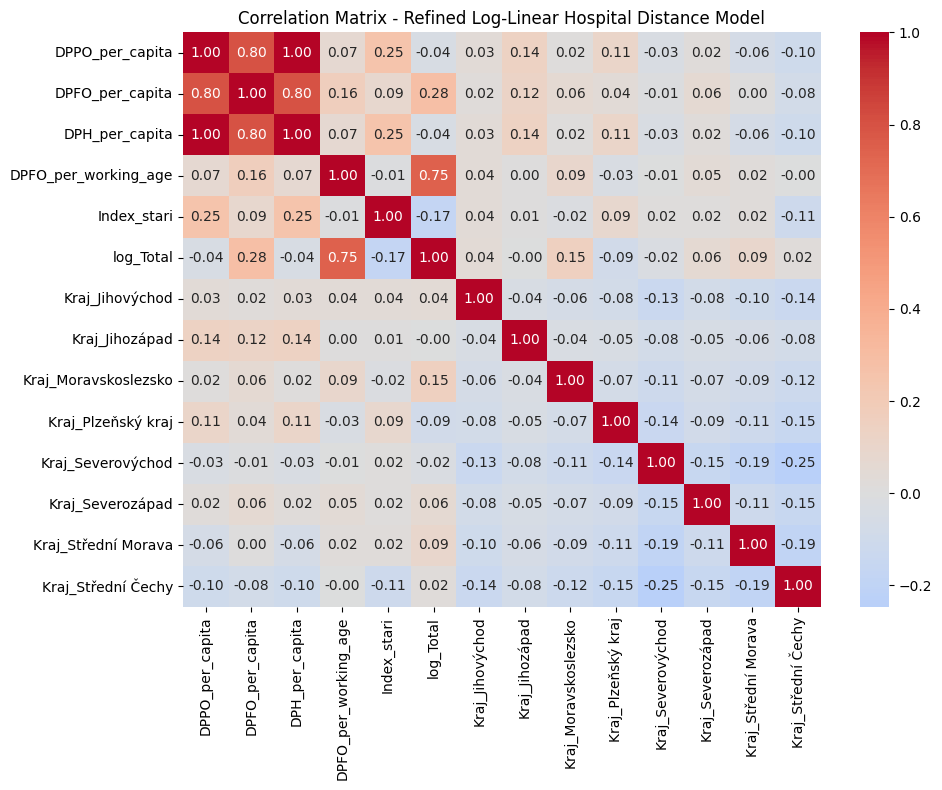

Variance Inflation Factor (VIF):
                      Features    VIF Factor
14                 Index_stari  1.150000e+00
2         C(Kraj)[T.Jihozápad]  1.320000e+00
4   C(Kraj)[T.Moravskoslezsko]  1.610000e+00
1        C(Kraj)[T.Jihovýchod]  1.780000e+00
5     C(Kraj)[T.Plzeňský kraj]  1.880000e+00
7       C(Kraj)[T.Severozápad]  1.950000e+00
3     C(Kraj)[T.Kraj Vysočina]  2.100000e+00
8    C(Kraj)[T.Střední Morava]  2.320000e+00
13        DPFO_per_working_age  2.730000e+00
6      C(Kraj)[T.Severovýchod]  2.860000e+00
9     C(Kraj)[T.Střední Čechy]  2.900000e+00
15                   log_Total  3.750000e+00
11             DPFO_per_capita  4.420000e+00
0                    Intercept  2.178100e+02
10             DPPO_per_capita  2.455549e+11
12              DPH_per_capita  2.455549e+11
------------------------------------------------


In [14]:
data_for_testing = pd.get_dummies(cities_df_selected[keep_cols + ['log_distance_km']], 
                                  columns=['Kraj'], drop_first=True)

perform_all_tests(refined_model, 
                  data_=data_for_testing, 
                  features=selected_features, 
                  model_name="Refined Log-Linear Hospital Distance Model",
                  y_col="log_distance_km")

In [15]:
# drop_cols = ['DPPO_per_capita', 'DPH_per_capita']

# for col in drop_cols:
#     if col in selected_features:
#         selected_features.remove(col)
# features_model = selected_features


# data_for_testing = pd.get_dummies(cities_df_selected[keep_cols + ['log_Vzdalenost_km']], 
#                                   columns=['Kraj'], drop_first=True)

# data_for_testing = data_for_testing.drop(columns=drop_cols, errors='ignore')

# manual_formula = "Vzdalenost_km ~ " + " + ".join(features_model)
# if kraj_kept:
#     manual_formula += " + C(Kraj)"



# manual_model = smf.ols(manual_formula, data=cities_df_selected).fit(cov_type="HC3")

# perform_all_tests(manual_model, 
#                   data_=data_for_testing, 
#                   features=features_model, 
#                   model_name="Distance to hospital vs. Socioeconomic factors",
#                   y_col="Vzdalenost_km")

In [16]:
cities_df_selected['log_Total_sq'] = cities_df_selected['log_Total'] ** 2
#cities_df_selected['DPFO_per_capita_sq'] = cities_df_selected['DPFO_per_capita'] ** 2

poly_formula = refined_formula + " + log_Total_sq" #+ DPFO_per_capita_sq"
poly_model = smf.ols(poly_formula, data=cities_df_selected).fit(cov_type="HC3")
print(poly_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_distance_km   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     66.70
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          1.35e-197
Time:                        21:38:42   Log-Likelihood:                -4637.2
No. Observations:                5497   AIC:                             9308.
Df Residuals:                    5480   BIC:                             9421.
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [17]:
print(poly_model.summary2().tables[1])

                                 Coef.    Std.Err.         z         P>|z|  \
Intercept                     3.485342    0.602078  5.788850  7.086990e-09   
C(Kraj)[T.Jihovýchod]         0.009394    0.038528  0.243815  8.073742e-01   
C(Kraj)[T.Jihozápad]         -0.001268    0.053354 -0.023774  9.810327e-01   
C(Kraj)[T.Kraj Vysočina]     -0.018043    0.032493 -0.555302  5.786879e-01   
C(Kraj)[T.Moravskoslezsko]   -0.134572    0.042315 -3.180270  1.471378e-03   
C(Kraj)[T.Plzeňský kraj]      0.003041    0.036065  0.084324  9.327989e-01   
C(Kraj)[T.Severovýchod]       0.151817    0.032041  4.738174  2.156521e-06   
C(Kraj)[T.Severozápad]       -0.300343    0.035731 -8.405614  4.256301e-17   
C(Kraj)[T.Střední Morava]    -0.109502    0.031563 -3.469344  5.217310e-04   
C(Kraj)[T.Střední Čechy]     -0.110704    0.029340 -3.773143  1.612037e-04   
DPPO_per_capita             123.874215  289.557181  0.427806  6.687926e-01   
DPFO_per_capita               0.038111    0.011207  3.400572  6.

TEST LINEARITY


/home/jansapro/.local/lib/python3.10/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


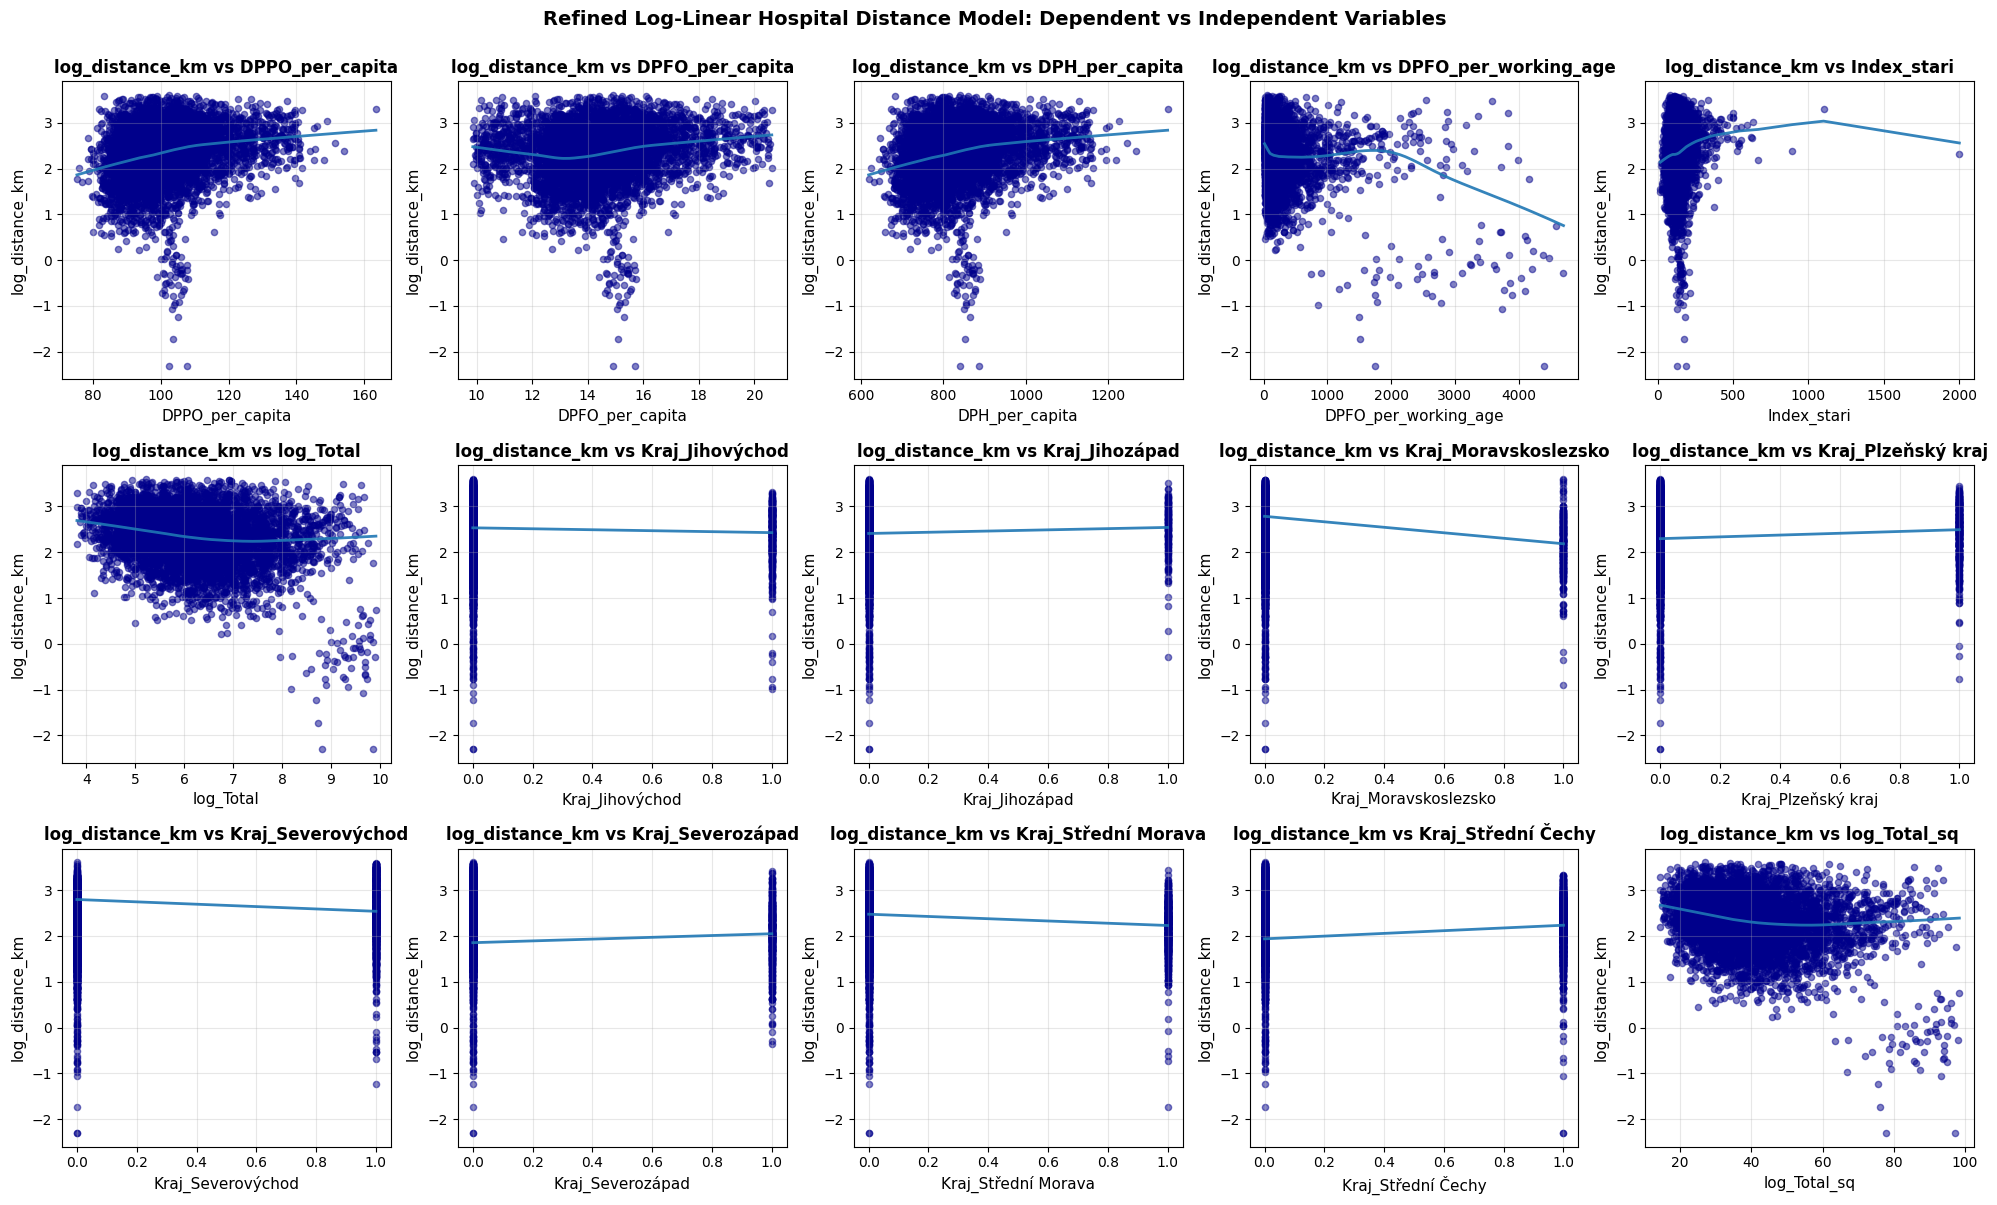

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



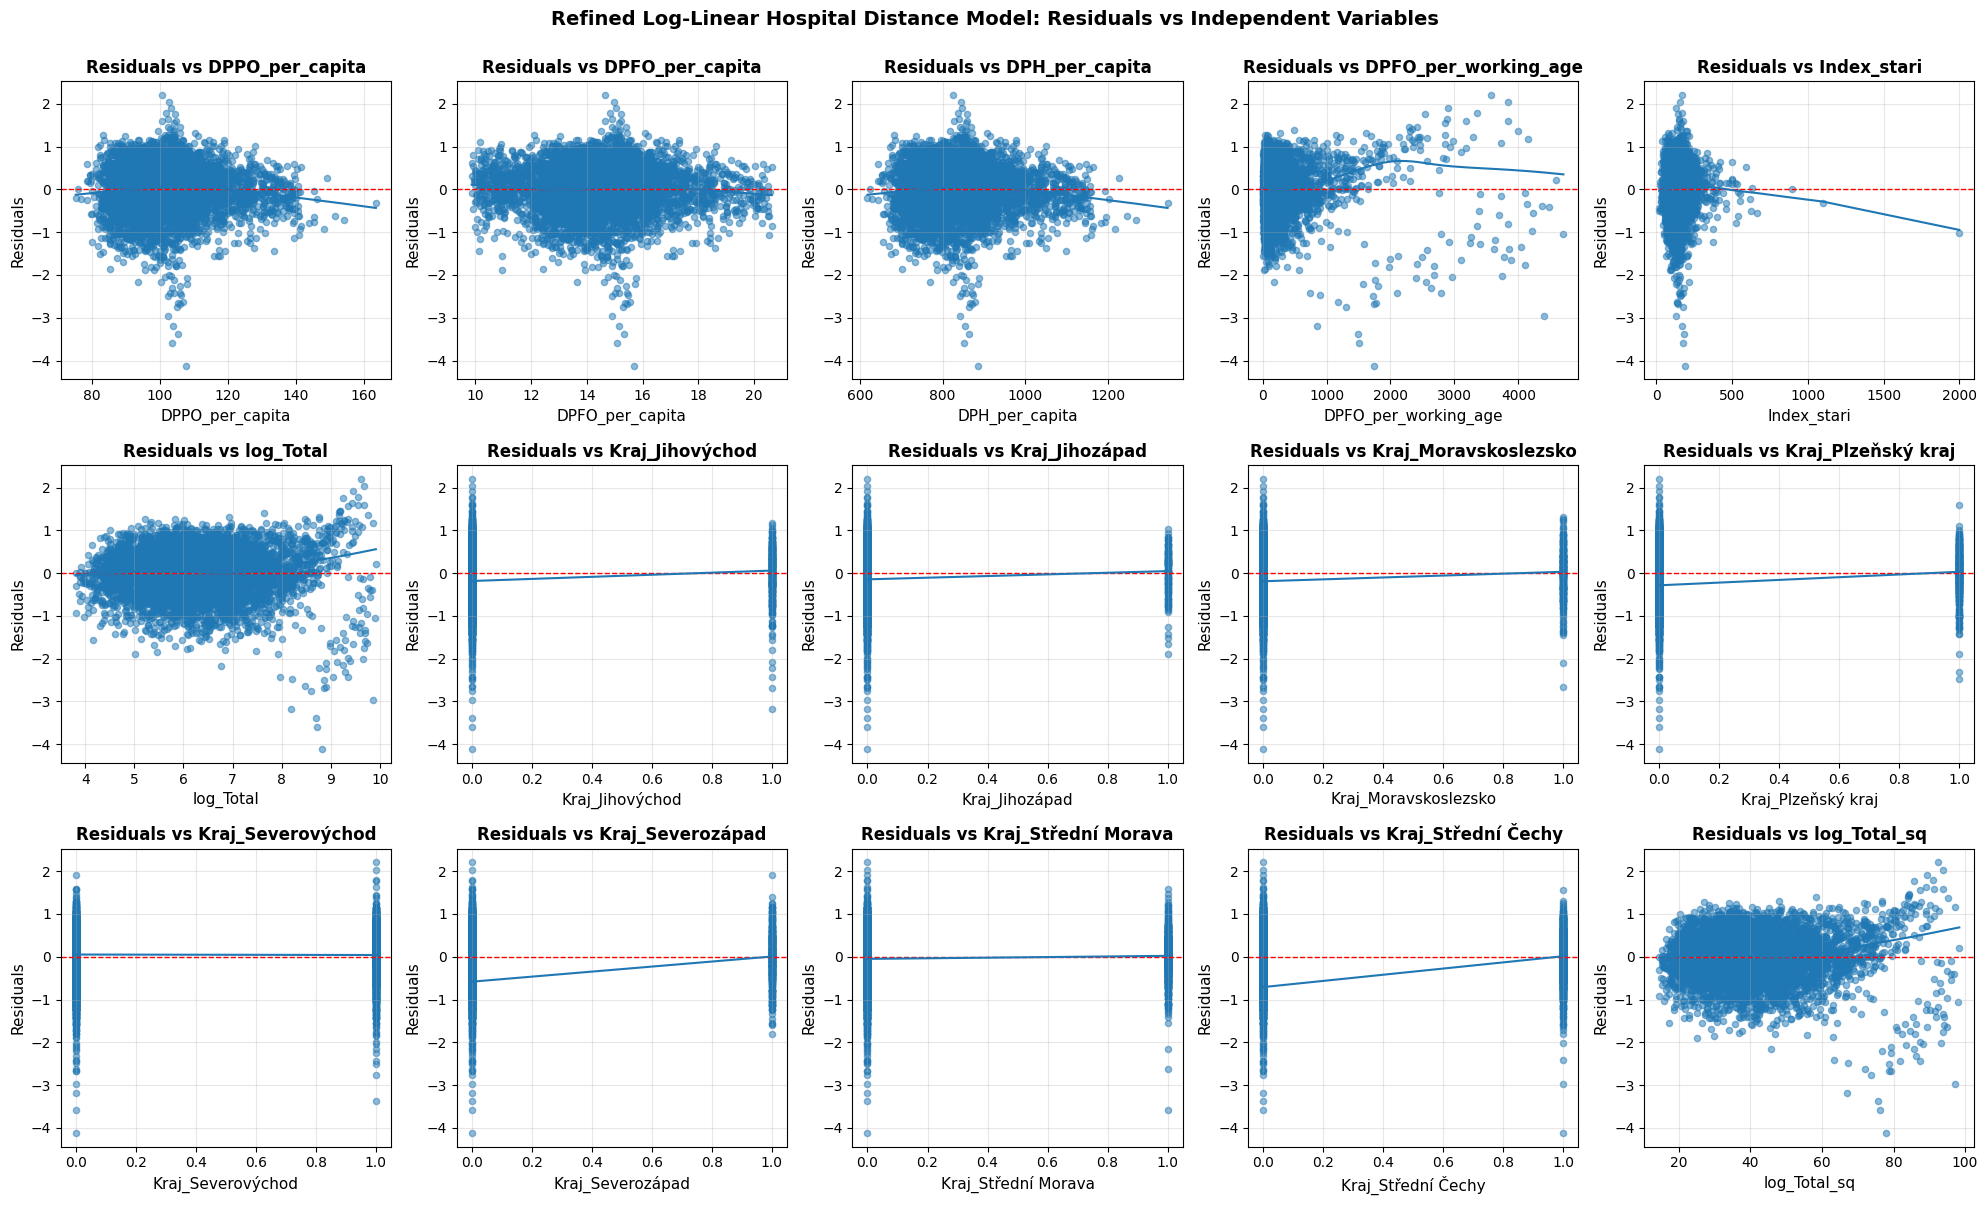

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Refined Log-Linear Hospital Distance Model: 2.698e-149 (LM stat=754.113)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Refined Log-Linear Hospital Distance Model: 1.588
Ljung–Box test results for Refined Log-Linear Hospital Distance Model (lags [10, 20, 40]):
        lb_stat      lb_pvalue
10  1451.066415  9.327109e-306
20  2499.230254   0.000000e+00
40  3374.882396   0.000000e+00


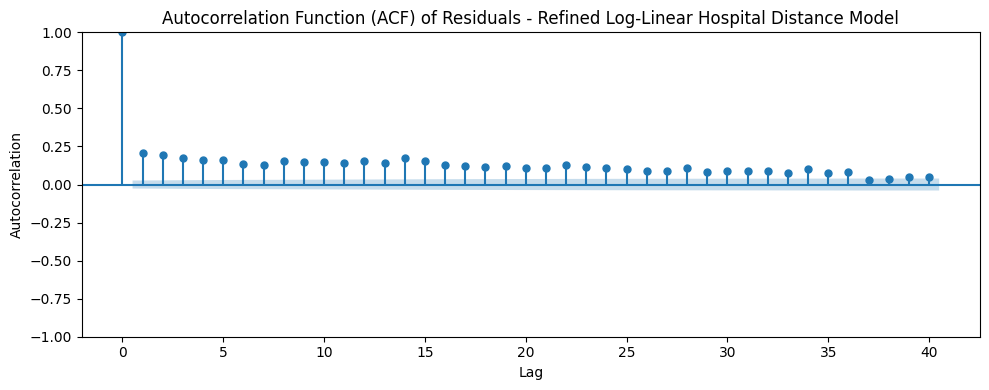

------------------------------------------------
TEST NORMALITY OF ERRORS


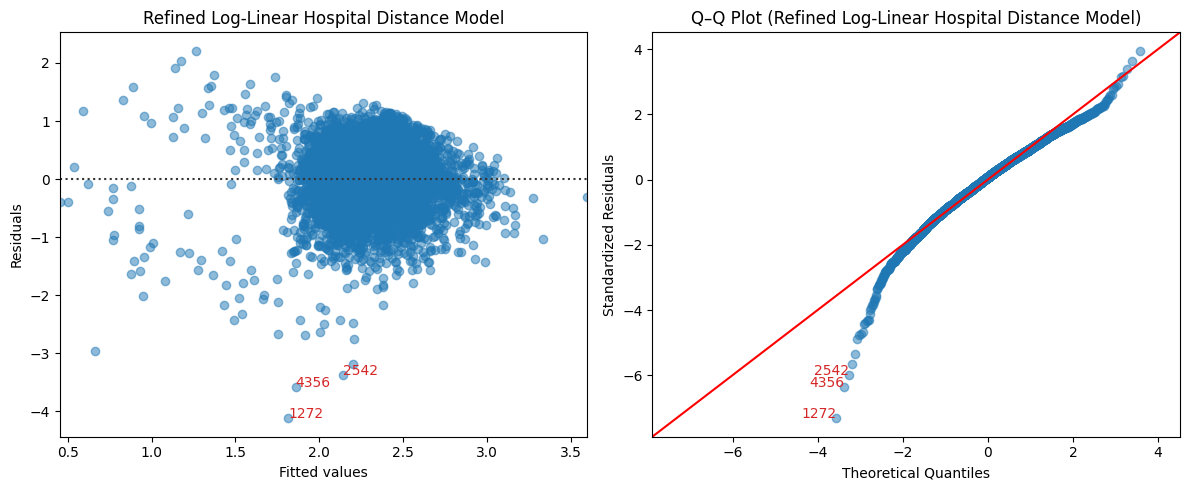

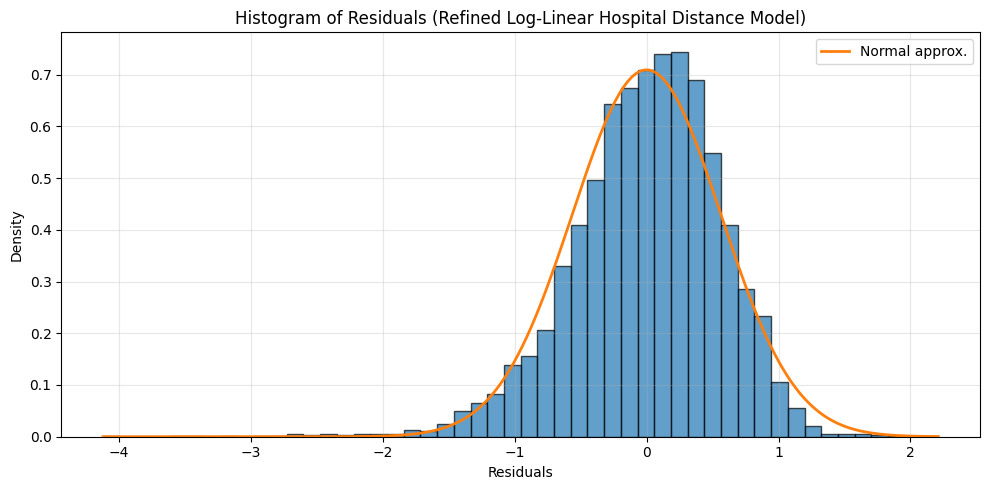

/usr/lib/python3/dist-packages/scipy/stats/_morestats.py:1761: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Shapiro–Wilk test for Refined Log-Linear Hospital Distance Model: W=0.9756, p-value=1.189e-29
------------------------------------------------
TEST MULTICOLLINEARITY


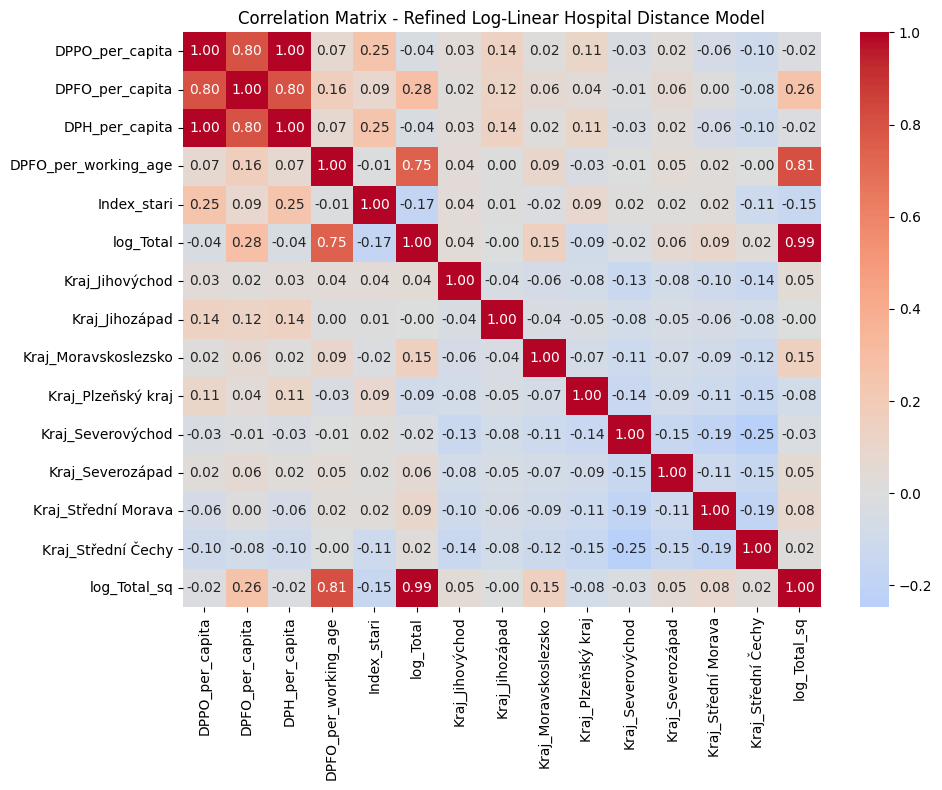

Variance Inflation Factor (VIF):
                      Features    VIF Factor
14                 Index_stari  1.160000e+00
2         C(Kraj)[T.Jihozápad]  1.320000e+00
4   C(Kraj)[T.Moravskoslezsko]  1.620000e+00
1        C(Kraj)[T.Jihovýchod]  1.780000e+00
5     C(Kraj)[T.Plzeňský kraj]  1.890000e+00
7       C(Kraj)[T.Severozápad]  1.950000e+00
3     C(Kraj)[T.Kraj Vysočina]  2.100000e+00
8    C(Kraj)[T.Střední Morava]  2.320000e+00
6      C(Kraj)[T.Severovýchod]  2.860000e+00
9     C(Kraj)[T.Střední Čechy]  2.900000e+00
11             DPFO_per_capita  8.000000e+00
13        DPFO_per_working_age  1.352000e+01
15                   log_Total  5.655400e+02
16                log_Total_sq  6.602600e+02
0                    Intercept  4.706710e+03
10             DPPO_per_capita  2.455884e+11
12              DPH_per_capita  2.455884e+11
------------------------------------------------


In [19]:
data_for_testing = pd.get_dummies(cities_df_selected[keep_cols + ['log_distance_km', 'log_Total_sq']], 
                                  columns=['Kraj'], drop_first=True)

perform_all_tests(poly_model, 
                  data_=data_for_testing,
                  features=selected_features+['log_Total_sq'],
                  model_name="Refined Log-Linear Hospital Distance Model",
                  y_col="log_distance_km")

In [ ]:
import statsmodels.api as sm

# Use the same formula but fit using RLM (Robust Linear Model)
# This is less sensitive to the 'heavy tails' seen in your Q-Q plot
robust_model = smf.rlm(refined_formula, data=cities_df_selected, M=sm.robust.norms.HuberT()).fit()

print(robust_model.summary())


                    Robust linear Model Regression Results                    
Dep. Variable:        log_distance_km   No. Observations:                 5497
Model:                            RLM   Df Residuals:                     5481
Method:                          IRLS   Df Model:                           15
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sat, 20 Dec 2025                                         
Time:                        20:50:49                                         
No. Iterations:                    50                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

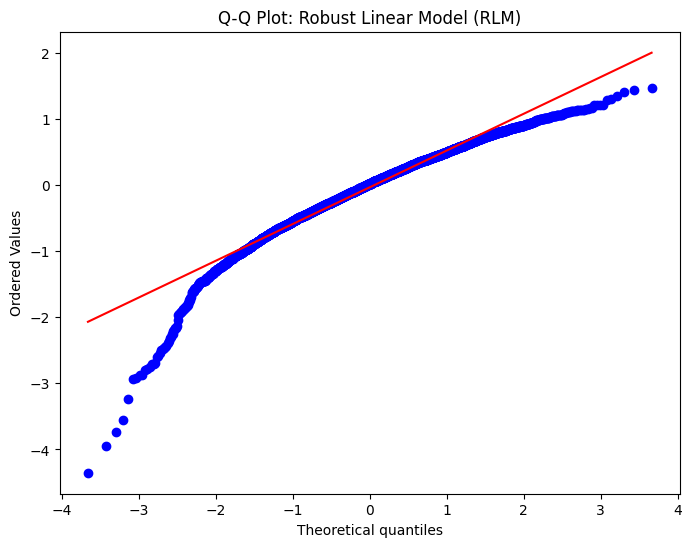

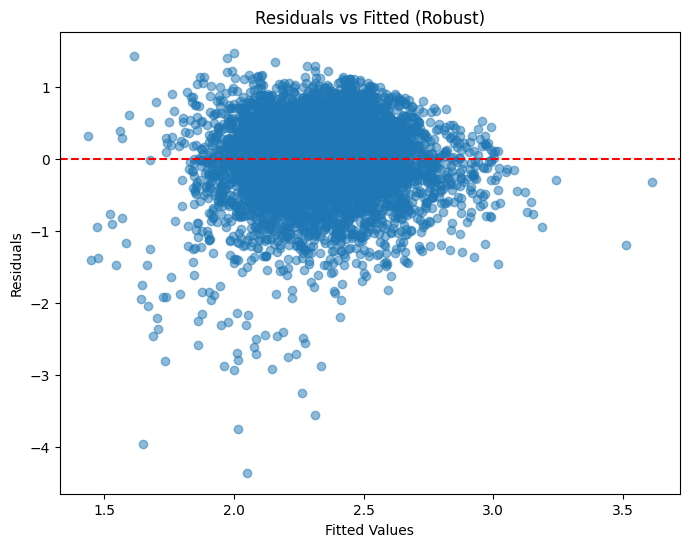

In [ ]:
import scipy.stats as stats

resids = robust_model.resid

# 3. Manual Q-Q Plot
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(resids, dist="norm", plot=ax)
ax.set_title("Q-Q Plot: Robust Linear Model (RLM)")
plt.show()

# 4. Residuals vs Fitted
plt.figure(figsize=(8, 6))
plt.scatter(robust_model.fittedvalues, resids, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Robust)")
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# fit(q=0.5) is Median Regression
median_model = smf.quantreg(formula, data=cities_df).fit(q=0.5)
print(median_model.summary())

                         QuantReg Regression Results                          
Dep. Variable:          Vzdalenost_km   Pseudo R-squared:              0.08399
Model:                       QuantReg   Bandwidth:                       1.507
Method:                 Least Squares   Sparsity:                        13.41
Date:                Sat, 20 Dec 2025   No. Observations:                 5497
Time:                        20:50:49   Df Residuals:                     5480
                                        Df Model:                           16
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      1.6220      1.855      0.875      0.382      -2.014       5.258
C(Kraj)[T.Jihovýchod]          0.1036      0.477      0.217      0.828      -0.831       1.038
C(Kraj)[T.Jihozápad]           0.3074      0.668      0.460      0.